
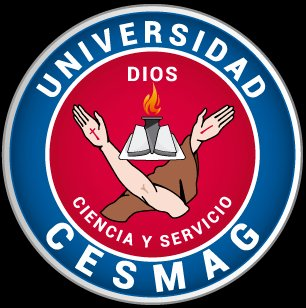

In [ ]:
#@title  Notebook 04B — Multi-Sujeto ECG
#@markdown (portada — no modificar)
from IPython.display import display, HTML
display(HTML("""
  <!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Crimson+Pro:ital,wght@0,300;0,400;0,600;1,300&family=JetBrains+Mono:wght@400;600&family=Barlow+Condensed:wght@300;400;700;900&display=swap');

  :root {
    --azul-cesmag: #003b7a;
    --rojo-cesmag: #c0002a;
    --dorado: #c9a84c;
    --crema: #f7f4ee;
    --gris-oscuro: #1a1a2e;
    --gris-medio: #4a4a6a;
    --blanco: #ffffff;
    --verde-ok: #2d9c5a;
    --pulso: #e8325a;
  }

  * { margin: 0; padding: 0; box-sizing: border-box; }

  body { font-family: 'Barlow Condensed', sans-serif; background: transparent; }

  .wrapper {
    width: 100%;
    background: var(--gris-oscuro);
    border-radius: 16px;
    overflow: hidden;
    position: relative;
    box-shadow: 0 24px 80px rgba(0,0,0,0.5);
  }

  .ecg-bg {
    position: absolute; top: 0; left: 0; right: 0; bottom: 0;
    opacity: 0.04; pointer-events: none; overflow: hidden;
  }
  .ecg-bg svg { width: 200%; height: 100%; animation: scrollECG 18s linear infinite; }
  @keyframes scrollECG { from { transform: translateX(0); } to { transform: translateX(-50%); } }

  .header {
    background: linear-gradient(135deg, var(--azul-cesmag) 0%, #001f4d 60%, #0a0a2a 100%);
    padding: 36px 48px 28px;
    display: grid;
    grid-template-columns: 110px 1fr;
    gap: 32px;
    align-items: center;
    position: relative;
    border-bottom: 3px solid var(--dorado);
  }
  .header::after {
    content: '';
    position: absolute; bottom: -3px; left: 0; right: 0; height: 1px;
    background: linear-gradient(90deg, transparent, var(--dorado), transparent);
  }

  .logo-ring {
    width: 110px; height: 110px; border-radius: 50%; padding: 4px;
    background: conic-gradient(var(--dorado), var(--rojo-cesmag), var(--dorado));
    animation: rotatering 8s linear infinite; flex-shrink: 0;
  }
  @keyframes rotatering { to { filter: hue-rotate(30deg); } }
  .logo-inner {
    width: 100%; height: 100%; border-radius: 50%; overflow: hidden;
    border: 3px solid var(--gris-oscuro);
  }
  .logo-inner img { width: 100%; height: 100%; object-fit: cover; }

  .univ-label {
    font-weight: 300; font-size: 11px; letter-spacing: 4px;
    color: var(--dorado); text-transform: uppercase; margin-bottom: 4px;
  }
  .univ-name {
    font-weight: 900; font-size: 28px; color: var(--blanco);
    letter-spacing: 1px; line-height: 1;
  }
  .dept { font-size: 13px; font-weight: 400; color: rgba(255,255,255,0.6); letter-spacing: 2px; margin-top: 6px; }
  .notebook-badge {
    display: inline-flex; align-items: center; gap: 8px;
    background: var(--rojo-cesmag); color: white;
    font-family: 'JetBrains Mono', monospace; font-size: 11px; font-weight: 600;
    padding: 5px 14px; border-radius: 4px; margin-top: 12px; letter-spacing: 1px;
  }
  .notebook-badge::before { content: '▶'; font-size: 8px; }

  .title-section { padding: 32px 48px 24px; background: #111128; }
  .title-label {
    font-size: 10px; letter-spacing: 5px; color: var(--pulso);
    text-transform: uppercase; margin-bottom: 10px; font-weight: 400;
  }
  .main-title {
    font-family: 'Crimson Pro', serif; font-size: 34px; font-weight: 600;
    color: var(--blanco); line-height: 1.25; max-width: 820px;
  }
  .main-title em { font-style: italic; color: var(--dorado); }
  .subtitle {
    font-size: 14px; color: rgba(255,255,255,0.45);
    margin-top: 10px; letter-spacing: 1px; font-weight: 300;
  }

  .stats-band {
    display: grid; grid-template-columns: repeat(4, 1fr); background: #0c0c22;
    border-top: 1px solid rgba(201,168,76,0.2); border-bottom: 1px solid rgba(201,168,76,0.2);
  }
  .stat-box {
    padding: 18px 20px; text-align: center;
    border-right: 1px solid rgba(255,255,255,0.06); transition: background 0.3s;
  }
  .stat-box:last-child { border-right: none; }
  .stat-box:hover { background: rgba(201,168,76,0.05); }
  .stat-num {
    font-family: 'JetBrains Mono', monospace; font-size: 28px;
    font-weight: 600; color: var(--dorado); line-height: 1;
  }
  .stat-num span { font-size: 14px; color: rgba(201,168,76,0.6); }
  .stat-desc { font-size: 10px; letter-spacing: 2px; color: rgba(255,255,255,0.4); text-transform: uppercase; margin-top: 5px; }

  .body-grid { display: grid; grid-template-columns: 1fr 1fr; background: #12122a; }
  .section {
    padding: 28px 32px;
    border-right: 1px solid rgba(255,255,255,0.05);
    border-bottom: 1px solid rgba(255,255,255,0.05);
  }
  .section:nth-child(even) { border-right: none; }

  .sec-title {
    font-size: 9px; letter-spacing: 4px; text-transform: uppercase; color: var(--pulso);
    margin-bottom: 14px; display: flex; align-items: center; gap: 8px;
  }
  .sec-title::after { content: ''; flex: 1; height: 1px; background: rgba(232,50,90,0.3); }

  .model-list { display: flex; flex-direction: column; gap: 7px; }
  .model-item {
    display: flex; align-items: center; gap: 10px; padding: 8px 12px;
    background: rgba(255,255,255,0.03); border-radius: 6px;
    border-left: 3px solid transparent; transition: border-color 0.2s, background 0.2s;
  }
  .model-item:hover { background: rgba(255,255,255,0.07); }
  .model-item.winner { border-left-color: var(--dorado); }
  .model-item.good   { border-left-color: var(--verde-ok); }
  .model-item.bad    { border-left-color: var(--rojo-cesmag); }
  .model-tag { font-family: 'JetBrains Mono', monospace; font-size: 11px; font-weight: 600; color: var(--blanco); min-width: 70px; }
  .model-score { font-family: 'JetBrains Mono', monospace; font-size: 11px; color: rgba(255,255,255,0.5); margin-left: auto; }
  .crown { font-size: 10px; }

  .chip-grid { display: flex; flex-wrap: wrap; gap: 6px; }
  .chip {
    font-family: 'JetBrains Mono', monospace; font-size: 10px; padding: 4px 10px;
    border-radius: 4px; background: rgba(0,59,122,0.4);
    border: 1px solid rgba(0,59,122,0.8); color: rgba(255,255,255,0.8); letter-spacing: 0.5px;
  }
  .chip.highlight { background: rgba(201,168,76,0.15); border-color: rgba(201,168,76,0.5); color: var(--dorado); }
  .chip.alt { background: rgba(45,156,90,0.15); border-color: rgba(45,156,90,0.4); color: #5de89e; }

  .metric-row {
    display: flex; justify-content: space-between; align-items: center;
    padding: 7px 0; border-bottom: 1px solid rgba(255,255,255,0.04); font-size: 12px;
  }
  .metric-row:last-child { border-bottom: none; }
  .metric-name { color: rgba(255,255,255,0.5); font-weight: 300; letter-spacing: 1px; }
  .metric-val {
    font-family: 'JetBrains Mono', monospace; font-size: 11px; color: var(--blanco);
    background: rgba(255,255,255,0.06); padding: 2px 8px; border-radius: 3px;
  }

  .file-list { display: flex; flex-direction: column; gap: 5px; }
  .file-item {
    display: flex; align-items: center; gap: 8px;
    font-family: 'JetBrains Mono', monospace; font-size: 10px;
    color: rgba(255,255,255,0.55); padding: 5px 8px;
    border-radius: 4px; background: rgba(255,255,255,0.02);
  }
  .ftype { font-size: 8px; padding: 1px 5px; border-radius: 2px; font-weight: 600; letter-spacing: 1px; }
  .ftype.csv   { background: rgba(45,156,90,0.3);  color: #5de89e; }
  .ftype.png   { background: rgba(201,168,76,0.3); color: var(--dorado); }
  .ftype.json  { background: rgba(0,59,122,0.5);   color: #5fa8ff; }
  .ftype.keras { background: rgba(232,50,90,0.3);  color: #ff7a9a; }

  .authors-bar {
    background: linear-gradient(90deg, #001530, #0a0a2a, #001530);
    padding: 20px 48px; display: flex; align-items: center;
    justify-content: space-between; flex-wrap: wrap; gap: 16px;
    border-top: 1px solid rgba(201,168,76,0.2);
  }
  .authors-group { display: flex; flex-direction: column; gap: 6px; }
  .author-label { font-size: 8px; letter-spacing: 4px; text-transform: uppercase; color: rgba(255,255,255,0.3); }
  .author-names { display: flex; gap: 20px; flex-wrap: wrap; }
  .author { font-family: 'Crimson Pro', serif; font-size: 16px; color: var(--blanco); font-weight: 400; letter-spacing: 0.5px; }
  .asesor-block { text-align: right; }
  .asesor-name { font-family: 'Crimson Pro', serif; font-size: 15px; color: var(--dorado); font-style: italic; }

  .footer {
    background: #0a0a18; padding: 12px 48px;
    display: flex; justify-content: space-between; align-items: center;
  }
  .footer-date { font-family: 'JetBrains Mono', monospace; font-size: 10px; color: rgba(255,255,255,0.2); letter-spacing: 2px; }
  .footer-file { font-family: 'JetBrains Mono', monospace; font-size: 10px; color: rgba(232,50,90,0.5); letter-spacing: 1px; }

  .pulse-line { width: 100%; height: 40px; background: #0a0a18; position: relative; overflow: hidden; }
  .pulse-line svg { position: absolute; top: 0; left: 0; width: 200%; animation: pulsemove 3s linear infinite; }
  @keyframes pulsemove { from { transform: translateX(0); } to { transform: translateX(-50%); } }
</style>
</head>
<body>
<div class="wrapper">

  <div class="ecg-bg">
    <svg viewBox="0 0 1400 200" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,100 80,100 100,100 110,20 120,180 130,60 140,140 150,100 230,100 310,100 320,100 330,20 340,180 350,60 360,140 370,100 450,100 530,100 540,100 550,20 560,180 570,60 580,140 590,100 670,100 750,100 760,100 770,20 780,180 790,60 800,140 810,100 890,100 970,100 980,100 990,20 1000,180 1010,60 1020,140 1030,100 1110,100 1190,100 1200,100 1210,20 1220,180 1230,60 1240,140 1250,100 1330,100 1400,100" stroke="white" stroke-width="2" fill="none"/>
    </svg>
  </div>

  <!-- HEADER -->
  <div class="header">
    <div class="logo-ring">
      <div class="logo-inner">
        <img src="..." alt="Logo CESMAG">
      </div>
    </div>
    <div>
      <div class="univ-label">Universidad</div>
      <div class="univ-name">CESMAG</div>
      <div class="dept">Ingeniería de Sistemas · Grupo de Investigación</div>
      <div class="notebook-badge">04B_segmentos_60s.ipynb</div>
    </div>
  </div>

  <!-- TÍTULO -->
  <div class="title-section">
    <div class="title-label">Notebook 04B — Modelo Compuesto Multi-Sujeto · Cuarta Fase Experimental</div>
    <div class="main-title">
      Predicción <em>Multi-Sujeto</em> de Señales ECG<br>con Pool Global de Segmentos de 60 Segundos
    </div>
    <div class="subtitle">MIT-BIH · 48 pacientes · 60 s/paciente · 3 086 ventanas train · 795 ventanas test · Lookback = 5 latidos</div>
  </div>

  <!-- STATS -->
  <div class="stats-band">
    <div class="stat-box">
      <div class="stat-num">24</div>
      <div class="stat-desc">Configuraciones</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">6</div>
      <div class="stat-desc">Modelos</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">3</div>
      <div class="stat-desc">Pipelines óptimos</div>
    </div>
    <div class="stat-box">
      <div class="stat-num">0.73</div>
      <div class="stat-desc">Mejor R² global</div>
    </div>
  </div>

  <!-- BODY GRID -->
  <div class="body-grid">

    <!-- Ranking F_MED (mejor filtro) -->
    <div class="section">
      <div class="sec-title">Ranking Global · Filtro F_MED (mejor)</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">RF</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Random Forest</span>
          <span class="model-score">R²= 0.730</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Recurrente</span>
          <span class="model-score">R²= 0.724</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">MLP</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Perceptrón</span>
          <span class="model-score">R²= 0.711</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Recurrente</span>
          <span class="model-score">R²= 0.688</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">CNN-GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Híbrido</span>
          <span class="model-score">R²= 0.574</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">CNN-LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">Híbrido</span>
          <span class="model-score">R²= 0.573</span>
        </div>
      </div>
    </div>

    <!-- Promedio per-paciente (144 eval) -->
    <div class="section">
      <div class="sec-title">R² Medio Per-Paciente · 3 Filtros × 48 Pac.</div>
      <div class="model-list">
        <div class="model-item winner">
          <span class="crown">👑</span>
          <span class="model-tag">GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">N=144</span>
          <span class="model-score">0.436 ± 0.330</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">RF</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">N=144</span>
          <span class="model-score">0.430 ± 0.327</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">MLP</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">N=144</span>
          <span class="model-score">0.412 ± 0.375</span>
        </div>
        <div class="model-item good">
          <span class="crown">·</span>
          <span class="model-tag">LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">N=144</span>
          <span class="model-score">0.395 ± 0.336</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">CNN-GRU</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">N=144</span>
          <span class="model-score">0.265 ± 0.338</span>
        </div>
        <div class="model-item bad">
          <span class="crown">·</span>
          <span class="model-tag">CNN-LSTM</span>
          <span style="font-size:10px;color:rgba(255,255,255,0.4);">N=144</span>
          <span class="model-score">0.252 ± 0.296</span>
        </div>
      </div>
    </div>

    <!-- Config del experimento -->
    <div class="section">
      <div class="sec-title">Configuración del Experimento</div>
      <div class="chip-grid" style="margin-bottom:14px;">
        <span class="chip">GRU</span>
        <span class="chip">LSTM</span>
        <span class="chip">CNN-GRU</span>
        <span class="chip">CNN-LSTM</span>
        <span class="chip">RF</span>
        <span class="chip">MLP</span>
        <span class="chip alt">TD-CNN-GRU ★</span>
        <span class="chip alt">TD-CNN-LSTM ★</span>
        <span class="chip highlight">F_MED ★</span>
        <span class="chip highlight">F_N+MED ★</span>
        <span class="chip highlight">F_N+PB+MED</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Paradigma</span>
        <span class="metric-val">Pool multi-sujeto global</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Segmento por paciente</span>
        <span class="metric-val">60 s · ~86 latidos/pac.</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Optimizador / Loss</span>
        <span class="metric-val">Adam 0.001 · MSE</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Regularización</span>
        <span class="metric-val">L2 λ=0.0001 · Drop 0.2</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Early stopping / Épocas</span>
        <span class="metric-val">p=15 · máx. 100</span>
      </div>
      <div class="metric-row">
        <span class="metric-name">Mejor filtro</span>
        <span class="metric-val">F_MED (RF: R²=0.730)</span>
      </div>
    </div>

    <!-- Archivos generados -->
    <div class="section">
      <div class="sec-title">Archivos Generados</div>
      <div class="file-list">
        <div class="file-item"><span class="ftype csv">CSV</span>resultados_nb4b_global.csv (18 filas)</div>
        <div class="file-item"><span class="ftype csv">CSV</span>resultados_nb4b_por_paciente.csv (864 filas)</div>
        <div class="file-item"><span class="ftype csv">CSV</span>resumen, ic95, wilcoxon, r2_train_test</div>
        <div class="file-item"><span class="ftype csv">CSV</span>metadata_segmentos_60s.csv · checkpoints (×4)</div>
        <div class="file-item"><span class="ftype csv">CSV</span>resultados_td_cnn (global + por paciente)</div>
        <div class="file-item"><span class="ftype png">PNG</span>7 visualizaciones (boxplot, heatmap, scatter)</div>
        <div class="file-item"><span class="ftype json">JSON</span>config_NB4B.json</div>
        <div class="file-item"><span class="ftype keras">KERAS</span>modelos/ (18 + 6 configs globales)</div>
      </div>
    </div>

  </div>

  <!-- PULSE LINE -->
  <div class="pulse-line">
    <svg viewBox="0 0 1400 40" preserveAspectRatio="none" xmlns="http://www.w3.org/2000/svg">
      <polyline points="0,20 100,20 120,20 130,4 140,36 148,12 156,28 164,20 264,20 364,20 374,20 384,4 394,36 402,12 410,28 418,20 518,20 618,20 628,20 638,4 648,36 656,12 664,28 672,20 772,20 872,20 882,20 892,4 902,36 910,12 918,28 926,20 1026,20 1126,20 1136,20 1146,4 1156,36 1164,12 1172,28 1180,20 1280,20 1400,20"
        stroke="#e8325a" stroke-width="1.5" fill="none" opacity="0.6"/>
    </svg>
  </div>

  <!-- AUTHORS -->
  <div class="authors-bar">
    <div class="authors-group">
      <div class="author-label">Autores</div>
      <div class="author-names">
        <span class="author">Darwin David Burbano Guerrero</span>
        <span style="color:rgba(255,255,255,0.2);align-self:center;">·</span>
        <span class="author">Darío Esteban Gómez Ordóñez</span>
      </div>
    </div>
    <div class="asesor-block">
      <div class="author-label" style="text-align:right;">Asesor</div>
      <div class="asesor-name">Mg. Héctor Andrés Mora Paz</div>
    </div>
  </div>

  <!-- FOOTER -->
  <div class="footer">
    <div class="footer-date">ANÁLISIS: 29 · MAR · 2026</div>
    <div class="footer-file">04B_segmentos_60s.ipynb</div>
  </div>

</div>
</body>
</html>
"""))

## BLOQUE 1 — Instalación de dependencias

Instalación de paquetes necesarios (`wfdb`, `tensorflow`, `scipy`, etc.).

In [1]:
# ══════════════════════════════════════════════════════════════════
# CELDA 2 — Instalación de dependencias
# ══════════════════════════════════════════════════════════════════
import subprocess, sys

PAQUETES = [
    'wfdb', 'scipy', 'scikit-learn', 'statsmodels',
    'dtaidistance', 'matplotlib', 'seaborn',
    'pandas', 'numpy', 'psutil', 'tensorflow',
]
for p in PAQUETES:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)
print('Dependencias listas.')

Dependencias listas.


## BLOQUE 2 — Configuración global, imports y rutas

Semilla, hiperparámetros, constantes NB4B, detección de entorno y rutas.

In [2]:
# ══════════════════════════════════════════════════════════════════
# CELDA 3 — Config, imports, rutas
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, time, gc
import psutil
from joblib import dump as joblib_dump

import wfdb
from scipy import signal as spsig
from scipy.ndimage import median_filter
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA

try:
    from dtaidistance import dtw as dtw_lib
    USE_DTW_LIB = True
except ImportError:
    USE_DTW_LIB = False

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Reproducibilidad ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU / CPU ────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'GPU detectada: {gpus[0].name}')
else:
    print('Sin GPU — usando CPU')

# ── Parámetros MIT-BIH ──────────────────────────────────────────
FS          = 360
NYQUIST     = FS / 2
PROP_TRAIN  = 0.80
F_BAJO      = 0.5
F_ALTO      = 40.0
ORDEN_BUT   = 4
FREC_NOTCH  = 60.0
Q_NOTCH     = 30.0

# ── DL Hiperparámetros ───────────────────────────────────────────
EPOCHS       = 100
PATIENCE_ES  = 15
BATCH_SIZE   = 32
LR           = 1e-3
L2_REG       = 1e-4
DROPOUT      = 0.2
BEAT_LEN     = 256
N_LOOKBACK   = 5
BEAT_TYPES   = set('NLRBVAFaJfEjeSe/')

# ── NB4B Específicos ─────────────────────────────────────────────
DURACION_SEG    = 60                          # segundos fijos
DURACION_MUES   = DURACION_SEG * FS           # 21600 muestras
FILTROS_SEL     = ['F_N+PB+MED', 'F_N+MED', 'F_MED']

PALETA = {'GRU': '#1f77b4', 'LSTM': '#ff7f0e', 'CNN-LSTM': '#2ca02c',
          'CNN-GRU': '#d62728', 'RF': '#9467bd', 'MLP': '#8c564b'}

# ── 48 Pacientes MIT-BIH ────────────────────────────────────────
PACIENTES = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234',
]

# ── Rutas ─────────────────────────────────────────────────────────
def _detectar_entorno():
    try:
        import google.colab
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        _drive = '/content/drive/MyDrive'
        for nombre in ['FORECASTING-ECG', 'FORECASTING ECG']:
            ruta = os.path.join(_drive, nombre)
            if os.path.isdir(ruta):
                return 'colab', ruta
        return 'colab', os.path.join(_drive, 'FORECASTING-ECG')
    except ImportError:
        ruta = os.getcwd()
        for _ in range(5):
            if os.path.isdir(os.path.join(ruta, 'data')) or os.path.isdir(os.path.join(ruta, 'datos')):
                return 'local', ruta
            ruta = os.path.dirname(ruta)
        return 'local', os.getcwd()

ENTORNO, _BASE = _detectar_entorno()

def _resolver_ruta(base, opciones):
    for partes in opciones:
        r = os.path.join(base, *partes)
        if os.path.isdir(r):
            return r
    return os.path.join(base, *opciones[0])

RUTA_DATOS   = _resolver_ruta(_BASE, [('data', 'mit-bih'), ('datos', 'mit-bih')])
RUTA_RESULTS = os.path.join(_BASE, 'results', 'NB4B')
RUTA_MODELOS = os.path.join(RUTA_RESULTS, 'modelos')
os.makedirs(RUTA_RESULTS, exist_ok=True)
os.makedirs(RUTA_MODELOS, exist_ok=True)

ram = psutil.virtual_memory()
print('=' * 65)
print('  NB4B — Modelo Global con Segmentos de 60 s')
print('=' * 65)
print(f'  Entorno      : {ENTORNO}')
print(f'  Raíz proyecto: {_BASE}')
print(f'  Ruta datos   : {RUTA_DATOS}')
print(f'  Ruta results : {RUTA_RESULTS}')
print(f'  Ruta modelos : {RUTA_MODELOS}')
print(f'  TF version   : {tf.__version__}')
print(f'  SEED={SEED}  Split={int(PROP_TRAIN*100)}/{int((1-PROP_TRAIN)*100)}')
print(f'  Segmento={DURACION_SEG}s  BEAT_LEN={BEAT_LEN}  N_LOOKBACK={N_LOOKBACK}')
print(f'  Filtros: {FILTROS_SEL}')
print(f'  DL: EPOCHS={EPOCHS} BS={BATCH_SIZE} LR={LR}')
print(f'  RAM disp.: {ram.available/1e9:.1f} GB / {ram.total/1e9:.1f} GB')
print('=' * 65)

GPU detectada: /physical_device:GPU:0
Mounted at /content/drive
  NB4B — Modelo Global con Segmentos de 60 s
  Entorno      : colab
  Raíz proyecto: /content/drive/MyDrive/FORECASTING ECG
  Ruta datos   : /content/drive/MyDrive/FORECASTING ECG/data/mit-bih
  Ruta results : /content/drive/MyDrive/FORECASTING ECG/results/NB4B
  Ruta modelos : /content/drive/MyDrive/FORECASTING ECG/results/NB4B/modelos
  TF version   : 2.19.0
  SEED=42  Split=80/19
  Segmento=60s  BEAT_LEN=256  N_LOOKBACK=5
  Filtros: ['F_N+PB+MED', 'F_N+MED', 'F_MED']
  DL: EPOCHS=100 BS=32 LR=0.001
  RAM disp.: 11.2 GB / 13.6 GB


## BLOQUE 3 — Filtros ECG (heredados de NB2)

Tres cadenas de filtrado heredadas de NB2: `F_N+PB+MED`, `F_N+MED`, `F_MED`.

In [3]:
# ══════════════════════════════════════════════════════════════════
# CELDA 4 — Filtros (heredados de NB2)
# ══════════════════════════════════════════════════════════════════

def f_notch(s):
    b, a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS)
    return spsig.filtfilt(b, a, s)

def f_butter_bp(s):
    b, a = spsig.butter(ORDEN_BUT, [F_BAJO/NYQUIST, F_ALTO/NYQUIST], btype='band')
    return spsig.filtfilt(b, a, s)

def f_mediana(s):
    k = FS // 10
    k = k if k % 2 == 1 else k + 1
    return median_filter(s, size=k)

def aplica(senal, fns):
    s = senal.copy()
    for fn in fns:
        s = fn(s)
    return s

FILTROS_ALL = {
    'F_N+PB+MED': [f_notch, f_butter_bp, f_mediana],
    'F_N+MED'   : [f_notch, f_mediana],
    'F_MED'     : [f_mediana],
}

FILTROS = {k: v for k, v in FILTROS_ALL.items() if k in FILTROS_SEL}
print(f'Filtros NB4B: {list(FILTROS.keys())}')

Filtros NB4B: ['F_N+PB+MED', 'F_N+MED', 'F_MED']


## BLOQUE 4 — Carga de datos MIT-BIH + filtrado

Carga de señales crudas para los 48 pacientes y aplicación de los 3 filtros.
Extracción de R-peaks desde anotaciones MIT-BIH.

In [4]:
# ══════════════════════════════════════════════════════════════════
# CELDA 5 — Carga de datos + filtrado multi-filtro
# ══════════════════════════════════════════════════════════════════

def cargar_ecg(pid):
    """Carga señal cruda y anotaciones de un paciente MIT-BIH."""
    ruta = os.path.join(RUTA_DATOS, pid)
    try:
        record = wfdb.rdrecord(ruta, channels=[0])
        ann = wfdb.rdann(ruta, 'atr')
        return record.p_signal[:, 0].astype(np.float64), ann
    except Exception as e:
        print(f'  [!] Error cargando {pid}: {e}')
        return None, None

DATOS       = {}   # DATOS[pid][nom_f] = señal filtrada
ANOTACIONES = {}   # ANOTACIONES[pid]  = ann object
REGISTROS_OK = []

for pid in PACIENTES:
    s_raw, ann = cargar_ecg(pid)
    if s_raw is None:
        continue
    ANOTACIONES[pid] = ann
    DATOS[pid] = {}
    for nom_f, fns in FILTROS.items():
        DATOS[pid][nom_f] = aplica(s_raw, fns)
    REGISTROS_OK.append(pid)
    del s_raw

gc.collect()
print(f'\nPacientes cargados: {len(REGISTROS_OK)} / {len(PACIENTES)}')
print(f'Filtros por paciente: {list(FILTROS.keys())}')


Pacientes cargados: 48 / 48
Filtros por paciente: ['F_N+PB+MED', 'F_N+MED', 'F_MED']


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELDA 6 — R-peaks desde anotaciones MIT-BIH
# ══════════════════════════════════════════════════════════════════

RPEAKS = {}  # RPEAKS[pid] = array de posiciones de R-peaks

for pid in REGISTROS_OK:
    ann = ANOTACIONES[pid]
    mask = [s in BEAT_TYPES for s in ann.symbol]
    rp = ann.sample[mask]
    if len(rp) >= 10:
        RPEAKS[pid] = rp
    else:
        print(f'  [!] {pid}: solo {len(rp)} R-peaks, excluido.')

# Actualizar lista de pacientes válidos
REGISTROS_OK = [p for p in REGISTROS_OK if p in RPEAKS]
print(f'Pacientes con R-peaks válidos: {len(REGISTROS_OK)}')

Pacientes con R-peaks válidos: 48


## BLOQUE 5 — Extracción de segmentos de 60 s

Selección de la ventana de 60 s con mayor densidad de R-peaks por paciente.
Visualización de 3 pacientes de ejemplo.

In [6]:
# ══════════════════════════════════════════════════════════════════
# CELDA 7 — Extracción de segmentos de 60 s
#           (zona con mayor densidad de R-peaks)
# ══════════════════════════════════════════════════════════════════

def extraer_segmento_60s(rpeaks, senal_len):
    """Encuentra la ventana de DURACION_MUES muestras con más R-peaks.
    Retorna (inicio, rpeaks_relativos)."""
    if senal_len < DURACION_MUES:
        # Señal más corta que 60 s: usar toda
        rp_rel = rpeaks[rpeaks < senal_len]
        return 0, rp_rel

    mejor_inicio, mejor_count = 0, 0
    # Deslizar ventana con paso de 1 segundo
    for inicio in range(0, senal_len - DURACION_MUES + 1, FS):
        fin = inicio + DURACION_MUES
        count = np.sum((rpeaks >= inicio) & (rpeaks < fin))
        if count > mejor_count:
            mejor_count = count
            mejor_inicio = inicio

    fin = mejor_inicio + DURACION_MUES
    mask = (rpeaks >= mejor_inicio) & (rpeaks < fin)
    rp_rel = rpeaks[mask] - mejor_inicio
    return mejor_inicio, rp_rel


SEGMENTOS = {}  # SEGMENTOS[pid] = {'inicio': int, 'rpeaks_rel': array, 'n_beats': int}
meta_rows = []

for pid in REGISTROS_OK:
    nom_f0 = FILTROS_SEL[0]
    senal_len = len(DATOS[pid][nom_f0])
    inicio, rp_rel = extraer_segmento_60s(RPEAKS[pid], senal_len)
    dur_real = min(DURACION_MUES, senal_len - inicio) / FS

    SEGMENTOS[pid] = {
        'inicio': inicio,
        'rpeaks_rel': rp_rel,
        'n_beats': len(rp_rel),
        'dur_real_s': dur_real,
    }
    meta_rows.append({
        'Paciente': pid, 'inicio_mues': inicio,
        'n_rpeaks_seg': len(rp_rel), 'dur_real_s': round(dur_real, 2),
    })

df_meta = pd.DataFrame(meta_rows)
os.makedirs(RUTA_RESULTS, exist_ok=True)
df_meta.to_csv(os.path.join(RUTA_RESULTS, 'metadata_segmentos_60s.csv'), index=False)
print(f'Segmentos extraídos: {len(SEGMENTOS)}')
print(f'R-peaks por segmento: min={df_meta.n_rpeaks_seg.min()}, '
      f'max={df_meta.n_rpeaks_seg.max()}, media={df_meta.n_rpeaks_seg.mean():.0f}')
df_meta.head(10)

Segmentos extraídos: 48
R-peaks por segmento: min=55, max=142, media=88


,Paciente,inicio_mues,n_rpeaks_seg,dur_real_s
0,100,139680,81,60.0
1,101,30960,73,60.0
2,102,26280,75,60.0
3,103,74160,74,60.0
4,104,35640,75,60.0
5,105,448200,93,60.0
6,106,265320,86,60.0
7,107,398160,73,60.0
8,108,609840,72,60.0
9,109,0,91,60.0


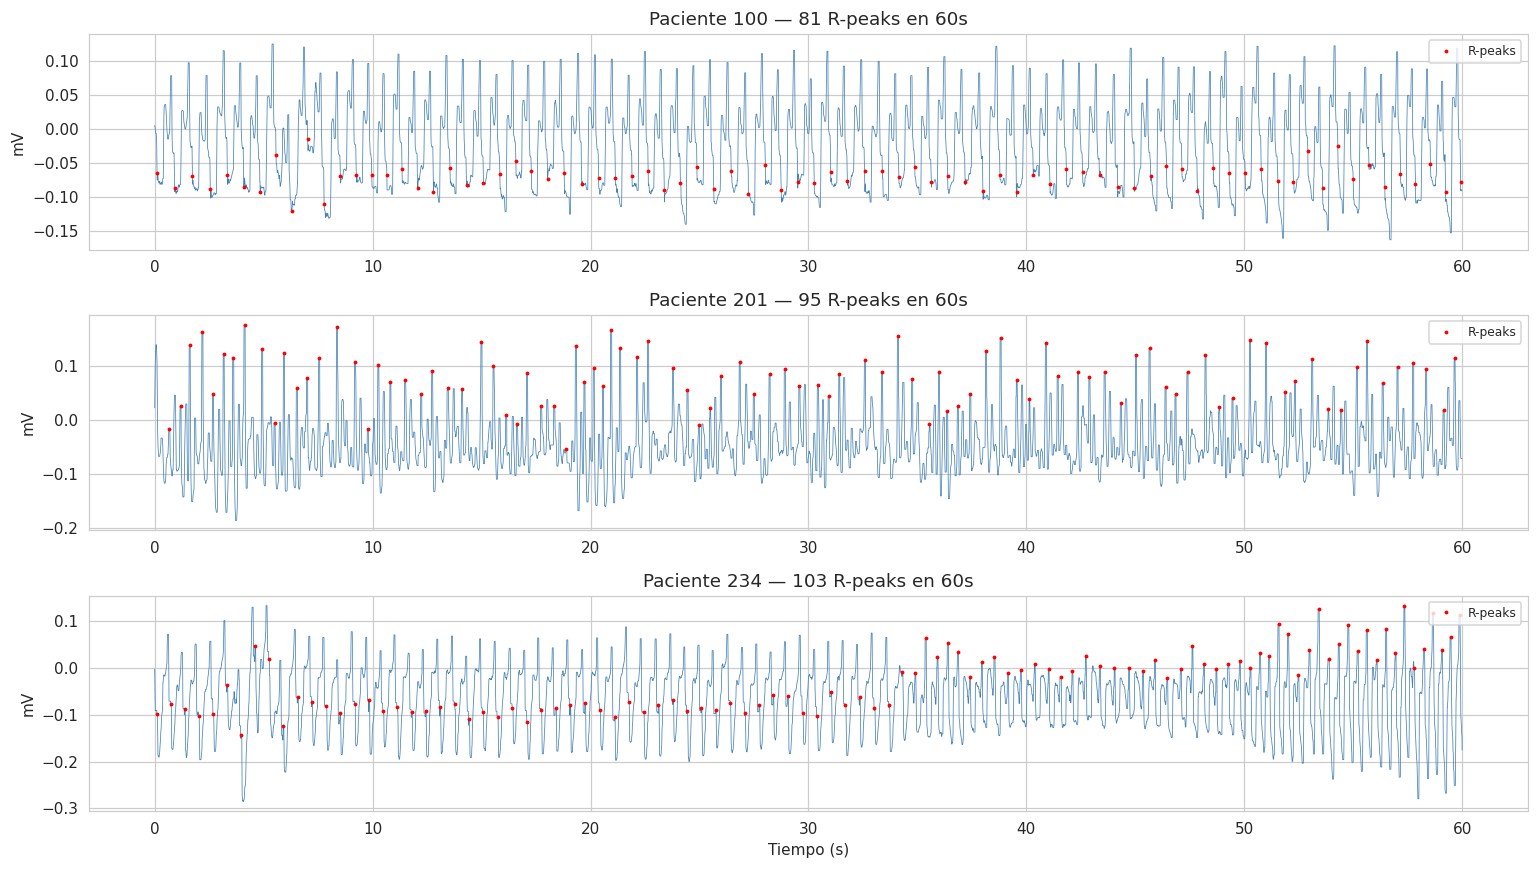

Guardado: ejemplo_segmentos_60s.png


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELDA 8 — Visualización de segmentos (3 pacientes ejemplo)
# ══════════════════════════════════════════════════════════════════

pids_ejemplo = [REGISTROS_OK[0],
                REGISTROS_OK[len(REGISTROS_OK)//2],
                REGISTROS_OK[-1]]
nom_f0 = FILTROS_SEL[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
for ax, pid in zip(axes, pids_ejemplo):
    seg = SEGMENTOS[pid]
    ini = seg['inicio']
    fin = ini + DURACION_MUES
    senal = DATOS[pid][nom_f0][ini:fin]
    t = np.arange(len(senal)) / FS
    ax.plot(t, senal, lw=0.5, color='steelblue')
    rp = seg['rpeaks_rel']
    rp_valid = rp[rp < len(senal)]
    ax.plot(rp_valid / FS, senal[rp_valid], 'r.', ms=3, label='R-peaks')
    ax.set_title(f'Paciente {pid} — {len(rp_valid)} R-peaks en {DURACION_SEG}s')
    ax.set_ylabel('mV')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'ejemplo_segmentos_60s.png'), dpi=150)
plt.show()
print('Guardado: ejemplo_segmentos_60s.png')

## BLOQUE 6 — Segmentación por latidos y ventanas

Funciones `extraer_latidos`, `secuencias_latidos`, `split_temporal` y `zscore_3d`
(idénticas a NB2, Exp B).

In [8]:
# ══════════════════════════════════════════════════════════════════
# CELDA 9 — Funciones de segmentación Exp B (idénticas a NB2)
# ══════════════════════════════════════════════════════════════════

def extraer_latidos(senal_seg, rpeaks_rel, beat_len=BEAT_LEN):
    """Extrae latidos usando R-peaks relativos al segmento.
    Corte en punto medio entre R-peaks consecutivos, resample a beat_len."""
    rp = rpeaks_rel
    if len(rp) < 3:
        return np.empty((0, beat_len), dtype=np.float32)
    beats = []
    for i in range(1, len(rp) - 1):
        start = (rp[i-1] + rp[i]) // 2
        end   = (rp[i]   + rp[i+1]) // 2
        seg   = senal_seg[start:end]
        if len(seg) < 50:
            continue
        beats.append(spsig.resample(seg, beat_len).astype(np.float32))
    if beats:
        return np.array(beats, dtype=np.float32)
    return np.empty((0, beat_len), dtype=np.float32)


def secuencias_latidos(beats, n_lookback=N_LOOKBACK):
    """X = (batch, n_lookback, beat_len), y = (batch, beat_len)."""
    if len(beats) <= n_lookback:
        return (np.empty((0, n_lookback, BEAT_LEN), dtype=np.float32),
                np.empty((0, BEAT_LEN), dtype=np.float32))
    X = np.array([beats[i:i+n_lookback] for i in range(len(beats) - n_lookback)])
    y = np.array([beats[i + n_lookback]  for i in range(len(beats) - n_lookback)])
    return X.astype(np.float32), y.astype(np.float32)


def secuencias_latidos_flat(beats, n_lookback=N_LOOKBACK):
    """Versión aplanada para modelos tradicionales: X = (batch, n_lookback * beat_len)."""
    X, y = secuencias_latidos(beats, n_lookback)
    if len(X) == 0:
        return (np.empty((0, n_lookback * BEAT_LEN), dtype=np.float32),
                np.empty((0, BEAT_LEN), dtype=np.float32))
    return X.reshape(len(X), -1), y


def split_temporal(X, y, prop=PROP_TRAIN):
    """Split temporal estricto: primeros prop% → train, resto → test."""
    n = int(len(X) * prop)
    return X[:n], y[:n], X[n:], y[n:]


def zscore_3d(Xtr, Xte):
    """Z-score global: mu/std de Xtr, aplicado a ambos."""
    mu  = Xtr.mean()
    std = max(Xtr.std(), 1e-8)
    return (Xtr - mu) / std, (Xte - mu) / std, mu, std


def zscore_y(ytr, yte, mu, std):
    return (ytr - mu) / std, (yte - mu) / std


print(f'Funciones de segmentación definidas: BEAT_LEN={BEAT_LEN}, N_LOOKBACK={N_LOOKBACK}')

Funciones de segmentación definidas: BEAT_LEN=256, N_LOOKBACK=5


## BLOQUE 7 — Arquitecturas DL y modelos tradicionales

**DL (4):** GRU, LSTM, CNN-LSTM, CNN-GRU — arquitecturas de NB2.
**Trad (2):** RF (`MultiOutputRegressor`), MLP (`MLPRegressor`).

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELDA 10 — Arquitecturas DL (4 de NB2)
# ══════════════════════════════════════════════════════════════════

def build_lstm(input_shape, out_dim):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(128, return_sequences=True,
                    kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.LSTM(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim)
    ])

def build_gru(input_shape, out_dim):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(128, return_sequences=True,
                   kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.GRU(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim)
    ])

def build_cnn_lstm(input_shape, out_dim):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Conv1D(128, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.MaxPooling1D(2),
        layers.LSTM(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim)
    ])

def build_cnn_gru(input_shape, out_dim):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Conv1D(128, 3, activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG)),
        layers.MaxPooling1D(2),
        layers.GRU(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim)
    ])

MODELOS_DL = {
    'GRU'      : build_gru,
    'LSTM'     : build_lstm,
    'CNN-LSTM' : build_cnn_lstm,
    'CNN-GRU'  : build_cnn_gru,
}

print(f'Modelos DL ({len(MODELOS_DL)}): {list(MODELOS_DL.keys())}')

Modelos DL (4): ['GRU', 'LSTM', 'CNN-LSTM', 'CNN-GRU']


In [10]:
# ══════════════════════════════════════════════════════════════════
# CELDA 11 — Modelos tradicionales
#   RF (RandomForest) + MLP (MLPRegressor)
#   Configuración idéntica a NB1 (01_tradicionales.ipynb)
# ══════════════════════════════════════════════════════════════════

def entrenar_trad(nombre, Xtr_flat, ytr, Xte_flat, yte):
    """Entrena modelo tradicional (RF o MLP). Retorna (dict_metricas, modelo_entrenado).
    El modelo NO se borra aquí — el caller lo guarda y luego lo libera."""
    if nombre == 'RF':
        modelo = RandomForestRegressor(
            n_estimators=30, max_depth=10,
            max_features='sqrt', min_samples_leaf=2,
            random_state=SEED, n_jobs=-1
        )
    elif nombre == 'MLP':
        modelo = MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation='relu', solver='adam',
            max_iter=300, early_stopping=True,
            validation_fraction=0.15,
            random_state=SEED,
        )
    else:
        raise ValueError(f'Modelo tradicional desconocido: {nombre}')

    t0 = time.perf_counter()
    modelo.fit(Xtr_flat, ytr)
    t_fit = time.perf_counter() - t0

    # R² en TRAIN
    yp_train = modelo.predict(Xtr_flat)
    r2_train = round(float(r2_score(ytr.flatten(), yp_train.flatten())), 4)

    # R² en TEST
    t0 = time.perf_counter()
    yp_test = modelo.predict(Xte_flat)
    lat = (time.perf_counter() - t0) / max(len(Xte_flat), 1) * 1000

    met = calcular_metricas(yte, yp_test, lat)
    if met:
        met['R2_train'] = r2_train
        met['t_fit_s']  = round(t_fit, 3)
        met['epochs_ran'] = np.nan

    return met, modelo


MODELOS_TRAD = {'RF': 'RF', 'MLP': 'MLP'}
print(f'Modelos Trad ({len(MODELOS_TRAD)}): {list(MODELOS_TRAD.keys())}')


Modelos Trad (2): ['RF', 'MLP']


## BLOQUE 8 — Métricas y funciones de entrenamiento

DTW, R², MSE, RMSE, MAE + funciones `entrenar_dl` / `entrenar_trad`.

In [11]:
# ══════════════════════════════════════════════════════════════════
# CELDA 12 — Métricas (DTW por secuencia, idéntico a NB2)
# ══════════════════════════════════════════════════════════════════

def _dtw_manual(a, b):
    n, m = len(a), len(b)
    C = np.full((n+1, m+1), np.inf)
    C[0, 0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            C[i, j] = (a[i-1] - b[j-1])**2 + min(C[i-1, j], C[i, j-1], C[i-1, j-1])
    return float(np.sqrt(C[n, m]))

def dtw_score(y_real, y_pred, max_pts=500):
    try:
        yr = y_real.flatten()
        yp = y_pred.flatten()
        n = min(len(yr), max_pts)
        idx = np.random.default_rng(SEED).choice(len(yr), n, replace=False)
        a = yr[idx].astype(np.float64)
        b = yp[idx].astype(np.float64)
        d = dtw_lib.distance_fast(a, b) if USE_DTW_LIB else _dtw_manual(a, b)
        return round(float(d), 4) if np.isfinite(d) else np.nan
    except Exception:
        return np.nan

def calcular_metricas(y_real, y_pred, lat_ms):
    yr = np.asarray(y_real).flatten()
    yp = np.asarray(y_pred).flatten()
    m  = np.isfinite(yr) & np.isfinite(yp)
    if m.sum() < 5:
        return None
    yr, yp = yr[m], yp[m]
    mse = float(mean_squared_error(yr, yp))
    return {
        'R2'  : round(float(r2_score(yr, yp)), 4),
        'MSE' : round(mse, 6),
        'RMSE': round(float(np.sqrt(mse)), 6),
        'MAE' : round(float(mean_absolute_error(yr, yp)), 6),
        'DTW' : dtw_score(yr, yp),
        'Latencia_ms': round(float(lat_ms), 4),
    }

def entrenar_dl(nombre, build_fn, Xtr, ytr, Xte, yte):
    """Entrena modelo DL. Retorna (dict_metricas, modelo_entrenado).
    El modelo NO se borra aquí — el caller lo guarda y luego lo libera."""
    input_shape = Xtr.shape[1:]
    out_dim     = ytr.shape[1] if ytr.ndim > 1 else 1
    model       = build_fn(input_shape, out_dim)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='mse'
    )

    cbs = [
        callbacks.EarlyStopping(patience=PATIENCE_ES,
                                restore_best_weights=True, monitor='val_loss'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
    ]

    t0 = time.perf_counter()
    history = model.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.15, callbacks=cbs, verbose=0)
    t_fit = time.perf_counter() - t0

    yp_train = model.predict(Xtr, batch_size=BATCH_SIZE, verbose=0)
    r2_train = round(float(r2_score(ytr.flatten(), yp_train.flatten())), 4)

    t0 = time.perf_counter()
    yp_test = model.predict(Xte, batch_size=BATCH_SIZE, verbose=0)
    lat = (time.perf_counter() - t0) / max(len(Xte), 1) * 1000

    met = calcular_metricas(yte, yp_test, lat)
    if met:
        met['R2_train']   = r2_train
        met['t_fit_s']    = round(t_fit, 3)
        met['epochs_ran'] = len(history.history.get('loss', []))

    return met, model

print('Métricas y funciones de entrenamiento definidas.')

Métricas y funciones de entrenamiento definidas.


## BLOQUE 9 — Construcción del dataset global (pool)

Split temporal 80/20 intra-paciente → pool global.
48 pacientes contribuyen a **ambos** pools (train y test).

In [12]:
# ══════════════════════════════════════════════════════════════════
# CELDA 13 — Construcción del dataset global + pool
# ══════════════════════════════════════════════════════════════════

def construir_pool_global(nom_f):
    """Construye pools train/test globales para un filtro dado.
    Split temporal 80/20 INTRA-PACIENTE; los 48 contribuyen a ambos pools.
    Retorna: Xtr, ytr, Xte, yte, pids_tr, pids_te  (arrays numpy).
    """
    Xtr_list, ytr_list, pids_tr_list = [], [], []
    Xte_list, yte_list, pids_te_list = [], [], []
    stats = []

    for pid in REGISTROS_OK:
        seg  = SEGMENTOS[pid]
        ini  = seg['inicio']
        fin  = ini + DURACION_MUES
        senal_seg = DATOS[pid][nom_f][ini:fin]
        rp_rel    = seg['rpeaks_rel']

        beats = extraer_latidos(senal_seg, rp_rel)
        if len(beats) <= N_LOOKBACK:
            continue

        X, y = secuencias_latidos(beats)
        if len(X) < 5:
            continue

        Xtr, ytr, Xte, yte = split_temporal(X, y)

        if len(Xtr) > 0:
            Xtr_list.append(Xtr)
            ytr_list.append(ytr)
            pids_tr_list.extend([pid] * len(Xtr))
        if len(Xte) > 0:
            Xte_list.append(Xte)
            yte_list.append(yte)
            pids_te_list.extend([pid] * len(Xte))

        stats.append({'pid': pid, 'n_beats': len(beats),
                      'n_vent': len(X), 'n_tr': len(Xtr), 'n_te': len(Xte)})

    X_train = np.concatenate(Xtr_list, axis=0)
    y_train = np.concatenate(ytr_list, axis=0)
    X_test  = np.concatenate(Xte_list, axis=0)
    y_test  = np.concatenate(yte_list, axis=0)

    return (X_train, y_train, X_test, y_test,
            np.array(pids_tr_list), np.array(pids_te_list),
            pd.DataFrame(stats))


# Verificar con el primer filtro
Xtr_, ytr_, Xte_, yte_, pids_tr_, pids_te_, df_stats_ = construir_pool_global(FILTROS_SEL[0])
print(f'Pool global ({FILTROS_SEL[0]}):')
print(f'  X_train_pool: {Xtr_.shape}   y_train_pool: {ytr_.shape}')
print(f'  X_test_pool:  {Xte_.shape}   y_test_pool:  {yte_.shape}')
print(f'  Pacientes contribuyendo: {len(df_stats_)}')
print(f'  Ventanas train total: {len(Xtr_)}  |  test total: {len(Xte_)}')
del Xtr_, ytr_, Xte_, yte_, pids_tr_, pids_te_; gc.collect()
df_stats_.head(10)

Pool global (F_N+PB+MED):
  X_train_pool: (3086, 5, 256)   y_train_pool: (3086, 256)
  X_test_pool:  (795, 5, 256)   y_test_pool:  (795, 256)
  Pacientes contribuyendo: 48
  Ventanas train total: 3086  |  test total: 795


,pid,n_beats,n_vent,n_tr,n_te
0,100,79,74,59,15
1,101,71,66,52,14
2,102,73,68,54,14
3,103,72,67,53,14
4,104,73,68,54,14
5,105,91,86,68,18
6,106,84,79,63,16
7,107,71,66,52,14
8,108,70,65,52,13
9,109,89,84,67,17


## BLOQUE 10 — Entrenamiento — 3 filtros × 6 modelos = 18

Loop principal: `filtro (3) × modelo (6) = 18 entrenamientos`.
Evaluación global + 48 R² per-paciente. Checkpoint CSV tras cada filtro.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELDA 14 — Entrenamiento de modelos globales
#   Loop: filtro (3) × modelo (6) = 18 entrenamientos
#   Evaluación: global + 48 R² per-paciente
#   Guarda el MISMO modelo evaluado (sin re-entrenar)
#   Guarda mu/std de normalización por filtro (para inferencia)
# ══════════════════════════════════════════════════════════════════

CKPT_GLOBAL = os.path.join(RUTA_RESULTS, 'checkpoint_nb4b.csv')
CKPT_PERPAC = os.path.join(RUTA_RESULTS, 'checkpoint_nb4b_por_paciente.csv')

filas_global, filas_perpac = [], []
YA_HECHO = set()

if os.path.exists(CKPT_GLOBAL):
    _df = pd.read_csv(CKPT_GLOBAL)
    filas_global = _df.to_dict('records')
    YA_HECHO = set(zip(_df.Filtro, _df.Modelo))
    print(f'Checkpoint global: {len(filas_global)} filas previas.')
if os.path.exists(CKPT_PERPAC):
    filas_perpac = pd.read_csv(CKPT_PERPAC).to_dict('records')
    print(f'Checkpoint per-pac: {len(filas_perpac)} filas previas.')

t0_total = time.perf_counter()

for nom_f in FILTROS_SEL:
    print(f'\n{"="*65}')
    print(f'  FILTRO: {nom_f}')
    print(f'{"="*65}')

    # Construir pool global (48 pacientes → train + test)
    X_train, y_train, X_test, y_test, pids_tr, pids_te, df_st = construir_pool_global(nom_f)

    # Z-score global (solo sobre train)
    X_train_n, X_test_n, mu, std = zscore_3d(X_train, X_test)
    y_train_n, y_test_n = zscore_y(y_train, y_test, mu, std)

    # Guardar parámetros de normalización (necesarios para inferencia futura)
    norm_params = {'filtro': nom_f, 'mu': float(mu), 'std': float(std),
                   'n_train': len(X_train), 'n_test': len(X_test)}
    ruta_norm = os.path.join(RUTA_MODELOS, f'norm_{nom_f}.json')
    with open(ruta_norm, 'w') as f_norm:
        json.dump(norm_params, f_norm, indent=2)
    print(f'  Normalización guardada: norm_{nom_f}.json (mu={mu:.6f}, std={std:.6f})')

    # Versiones flat para modelos tradicionales
    Xtr_flat = X_train_n.reshape(len(X_train_n), -1)
    Xte_flat = X_test_n.reshape(len(X_test_n), -1)

    n_pac = len(df_st)
    print(f'  Pool: train={len(X_train_n)} test={len(X_test_n)} pacientes={n_pac}')

    # ── Modelos DL ───────────────────────────────────────────────
    for nom_dl, build_fn in MODELOS_DL.items():
        clave = (nom_f, nom_dl)
        if clave in YA_HECHO:
            print(f'  {nom_dl}: skip (ya hecho)'); continue

        print(f'  {nom_dl}: entrenando... ', end='', flush=True)
        tf.random.set_seed(SEED)
        np.random.seed(SEED)

        try:
            met, model_dl = entrenar_dl(nom_dl, build_fn, X_train_n, y_train_n,
                                        X_test_n, y_test_n)
        except Exception as e:
            print(f'ERROR: {e}'); keras.backend.clear_session(); gc.collect(); continue

        if met:
            fila = {'Filtro': nom_f, 'Modelo': nom_dl,
                    'n_pacientes': n_pac,
                    'n_ventanas_train': len(X_train_n),
                    'n_ventanas_test': len(X_test_n), **met}
            filas_global.append(fila)
            YA_HECHO.add(clave)
            print(f'R2_train={met["R2_train"]:+.4f} R2_test={met["R2"]:+.4f} '
                  f't={met["t_fit_s"]:.0f}s ep={met["epochs_ran"]}')

            # Métricas per-paciente (usa el MISMO modelo ya entrenado)
            for pid in REGISTROS_OK:
                mask_te = pids_te == pid
                mask_tr = pids_tr == pid
                if mask_te.sum() == 0:
                    continue
                Xp_te = X_test_n[mask_te]
                yp_te = y_test_n[mask_te]
                yp_pred = model_dl.predict(Xp_te, batch_size=BATCH_SIZE, verbose=0)
                met_p = calcular_metricas(yp_te, yp_pred, 0)
                if met_p:
                    filas_perpac.append({
                        'Filtro': nom_f, 'Modelo': nom_dl, 'Paciente': pid,
                        'n_ventanas_train': int(mask_tr.sum()),
                        'n_ventanas_test': int(mask_te.sum()),
                        'R2': met_p['R2'], 'MSE': met_p['MSE'],
                        'RMSE': met_p['RMSE'], 'MAE': met_p['MAE'],
                        'DTW': met_p['DTW'],
                    })

            # Guardar modelo DL (el mismo que reportó las métricas)
            ruta_modelo = os.path.join(RUTA_MODELOS, f'modelo_{nom_dl}_{nom_f}.keras')
            model_dl.save(ruta_modelo)
            print(f'    Modelo guardado: {os.path.basename(ruta_modelo)}')

            # Checkpoint después de cada modelo
            pd.DataFrame(filas_global).to_csv(CKPT_GLOBAL, index=False)
            pd.DataFrame(filas_perpac).to_csv(CKPT_PERPAC, index=False)
            print(f'    Checkpoint guardado ({len(filas_global)} modelos acumulados)')

            del model_dl; keras.backend.clear_session(); gc.collect()
        else:
            del model_dl; keras.backend.clear_session(); gc.collect()
            print('métricas nulas')

    # ── Modelos Tradicionales ────────────────────────────────────
    for nom_tr in MODELOS_TRAD:
        clave = (nom_f, nom_tr)
        if clave in YA_HECHO:
            print(f'  {nom_tr}: skip (ya hecho)'); continue

        print(f'  {nom_tr}: entrenando... ', end='', flush=True)

        try:
            met, modelo_tr = entrenar_trad(nom_tr, Xtr_flat.copy(), y_train_n.copy(),
                                           Xte_flat.copy(), y_test_n.copy())
        except Exception as e:
            print(f'ERROR: {e}'); gc.collect(); continue

        if met:
            fila = {'Filtro': nom_f, 'Modelo': nom_tr,
                    'n_pacientes': n_pac,
                    'n_ventanas_train': len(Xtr_flat),
                    'n_ventanas_test': len(Xte_flat), **met}
            filas_global.append(fila)
            YA_HECHO.add(clave)
            print(f'R2_train={met["R2_train"]:+.4f} R2_test={met["R2"]:+.4f} '
                  f't={met["t_fit_s"]:.0f}s')

            # Métricas per-paciente (usa el MISMO modelo ya entrenado)
            for pid in REGISTROS_OK:
                mask_te = pids_te == pid
                mask_tr = pids_tr == pid
                if mask_te.sum() == 0:
                    continue
                Xp_te = Xte_flat[mask_te]
                yp_te = y_test_n[mask_te]
                yp_pred = modelo_tr.predict(Xp_te)
                met_p = calcular_metricas(yp_te, yp_pred, 0)
                if met_p:
                    filas_perpac.append({
                        'Filtro': nom_f, 'Modelo': nom_tr, 'Paciente': pid,
                        'n_ventanas_train': int(mask_tr.sum()),
                        'n_ventanas_test': int(mask_te.sum()),
                        'R2': met_p['R2'], 'MSE': met_p['MSE'],
                        'RMSE': met_p['RMSE'], 'MAE': met_p['MAE'],
                        'DTW': met_p['DTW'],
                    })

            # Guardar modelo tradicional (el mismo que reportó las métricas)
            ruta_modelo = os.path.join(RUTA_MODELOS, f'modelo_{nom_tr}_{nom_f}.pkl')
            joblib_dump(modelo_tr, ruta_modelo)
            print(f'    Modelo guardado: {os.path.basename(ruta_modelo)}')

            # Checkpoint después de cada modelo
            pd.DataFrame(filas_global).to_csv(CKPT_GLOBAL, index=False)
            pd.DataFrame(filas_perpac).to_csv(CKPT_PERPAC, index=False)
            print(f'    Checkpoint guardado ({len(filas_global)} modelos acumulados)')

            del modelo_tr; gc.collect()
        else:
            del modelo_tr; gc.collect()
            print('métricas nulas')

    del X_train, y_train, X_test, y_test, X_train_n, X_test_n
    del y_train_n, y_test_n, Xtr_flat, Xte_flat, pids_tr, pids_te
    gc.collect()

# Guardar resultados finales
df_global  = pd.DataFrame(filas_global)
df_perpac  = pd.DataFrame(filas_perpac)
df_global.to_csv(os.path.join(RUTA_RESULTS, 'resultados_nb4b_global.csv'), index=False)
df_perpac.to_csv(os.path.join(RUTA_RESULTS, 'resultados_nb4b_por_paciente.csv'), index=False)

t_total = (time.perf_counter() - t0_total) / 60
print(f'\n{"="*65}')
print(f'  ENTRENAMIENTO COMPLETADO — {t_total:.1f} min')
print(f'  Global: {len(df_global)} filas  |  Per-paciente: {len(df_perpac)} filas')
print(f'{"="*65}')
df_global

Checkpoint global: 4 filas previas.
Checkpoint per-pac: 192 filas previas.

  FILTRO: F_N+PB+MED
  Normalización guardada: norm_F_N+PB+MED.json (mu=-0.036191, std=0.222156)
  Pool: train=3086 test=795 pacientes=48
  GRU: skip (ya hecho)
  LSTM: skip (ya hecho)
  CNN-LSTM: skip (ya hecho)
  CNN-GRU: skip (ya hecho)
  RF: entrenando... R2_train=+0.7507 R2_test=+0.4932 t=13s
    Modelo guardado: modelo_RF_F_N+PB+MED.pkl
    Checkpoint guardado (5 modelos acumulados)
  MLP: entrenando... R2_train=+0.7319 R2_test=+0.4655 t=2s
    Modelo guardado: modelo_MLP_F_N+PB+MED.pkl
    Checkpoint guardado (6 modelos acumulados)

  FILTRO: F_N+MED
  Normalización guardada: norm_F_N+MED.json (mu=-0.360891, std=0.409455)
  Pool: train=3086 test=795 pacientes=48
  GRU: entrenando... R2_train=+0.7519 R2_test=+0.6957 t=22s ep=24
    Modelo guardado: modelo_GRU_F_N+MED.keras
    Checkpoint guardado (7 modelos acumulados)
  LSTM: entrenando... R2_train=+0.7035 R2_test=+0.6741 t=15s ep=19
    Modelo guardado:

,Filtro,Modelo,n_pacientes,n_ventanas_train,n_ventanas_test,R2,MSE,RMSE,MAE,DTW,Latencia_ms,R2_train,t_fit_s,epochs_ran
0,F_N+PB+MED,GRU,48,3086,795,0.4065,0.665912,0.816034,0.417293,15.9827,0.1804,0.5272,18.506,20.0
1,F_N+PB+MED,LSTM,48,3086,795,0.3823,0.693173,0.832570,0.425926,16.6112,0.1851,0.4997,17.958,19.0
2,F_N+PB+MED,CNN-LSTM,48,3086,795,0.3374,0.743460,0.862242,0.460012,18.2226,0.2349,0.4329,15.175,17.0
3,F_N+PB+MED,CNN-GRU,48,3086,795,0.3772,0.698838,0.835965,0.429705,17.2596,0.2505,0.5123,14.697,19.0
4,F_N+PB+MED,RF,48,3086,795,0.4932,0.568688,0.754114,0.385397,16.2495,0.0299,0.7507,12.513,NaN
5,F_N+PB+MED,MLP,48,3086,795,0.4655,0.599801,0.774468,0.397860,12.7744,0.0055,0.7319,2.220,NaN
6,F_N+MED,GRU,48,3086,795,0.6957,0.344177,0.586666,0.340715,11.8969,0.4334,0.7519,21.936,24.0
7,F_N+MED,LSTM,48,3086,795,0.6741,0.368680,0.607191,0.357613,12.1418,0.1658,0.7035,15.251,19.0
8,F_N+MED,CNN-LSTM,48,3086,795,0.5647,0.492343,0.701671,0.432851,14.2828,0.2174,0.5943,13.800,16.0
9,F_N+MED,CNN-GRU,48,3086,795,0.5941,0.459134,0.677594,0.412792,13.7070,0.1931,0.6178,12.423,16.0


## BLOQUE 11 — Análisis de resultados

R² train vs test (GAP), boxplots per-paciente, Friedman + Wilcoxon,
IC 95 %, heatmap, barras, scatter.

In [14]:
# ══════════════════════════════════════════════════════════════════
# CELDA 15 — R² global train vs test
# ══════════════════════════════════════════════════════════════════

df_global = pd.read_csv(os.path.join(RUTA_RESULTS, 'resultados_nb4b_global.csv'))

tabla_gap = df_global[['Filtro', 'Modelo', 'R2_train', 'R2']].copy()
tabla_gap.rename(columns={'R2': 'R2_test'}, inplace=True)
tabla_gap['GAP'] = tabla_gap['R2_train'] - tabla_gap['R2_test']
tabla_gap = tabla_gap.sort_values('R2_test', ascending=False)
tabla_gap.to_csv(os.path.join(RUTA_RESULTS, 'tabla_r2_train_test_nb4b.csv'), index=False)

print('R² Train vs Test (GAP = sobreajuste):')
display(tabla_gap.style.format({'R2_train': '{:+.4f}', 'R2_test': '{:+.4f}', 'GAP': '{:+.4f}'}))

R² Train vs Test (GAP = sobreajuste):


,Filtro,Modelo,R2_train,R2_test,GAP
16,F_MED,RF,+0.8645,+0.7295,+0.1350
10,F_N+MED,RF,+0.8662,+0.7292,+0.1370
12,F_MED,GRU,+0.8174,+0.7237,+0.0937
17,F_MED,MLP,+0.8228,+0.7109,+0.1119
11,F_N+MED,MLP,+0.8258,+0.7027,+0.1231
6,F_N+MED,GRU,+0.7519,+0.6957,+0.0562
13,F_MED,LSTM,+0.7193,+0.6875,+0.0318
7,F_N+MED,LSTM,+0.7035,+0.6741,+0.0294
9,F_N+MED,CNN-GRU,+0.6178,+0.5941,+0.0237
15,F_MED,CNN-GRU,+0.5975,+0.5736,+0.0239


Resumen R² per-paciente por modelo (sobre 48 pacientes × 3 filtros):


,μ_R2,σ_R2,min,max,n
Modelo,,,,,
GRU,+0.4363,0.3300,-0.2547,+0.9549,144
RF,+0.4304,0.3272,-0.3703,+0.9740,144
MLP,+0.4119,0.3751,-0.6855,+0.9610,144
LSTM,+0.3953,0.3359,-0.6893,+0.9675,144
CNN-GRU,+0.2654,0.3380,-1.1477,+0.9598,144
CNN-LSTM,+0.2517,0.2962,-0.6054,+0.9040,144


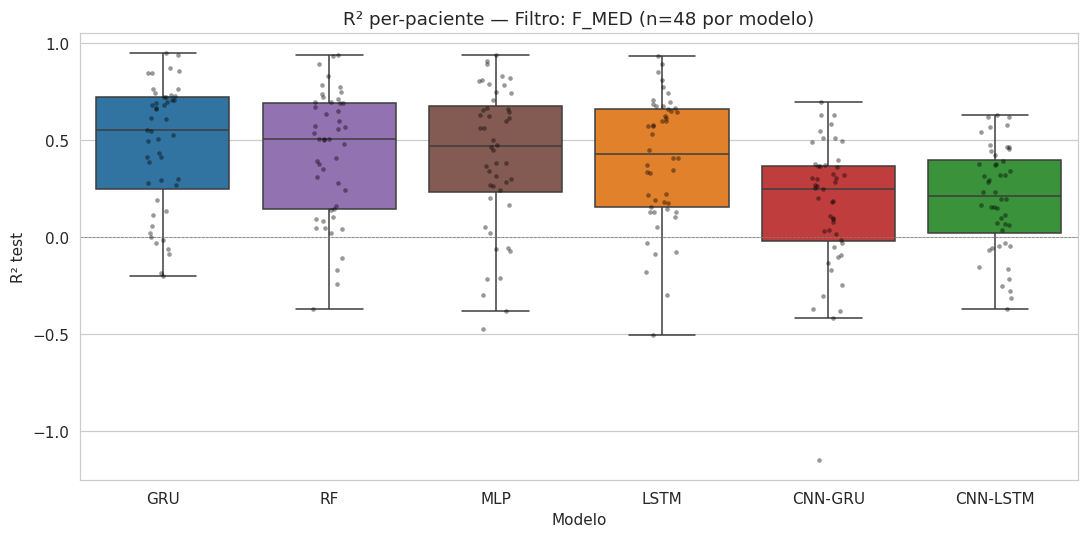

Guardado: boxplot_nb4b.png


In [15]:
# ══════════════════════════════════════════════════════════════════
# CELDA 16 — R² per-paciente (48 valores por modelo)
#   Fuente principal de variabilidad estadística
# ══════════════════════════════════════════════════════════════════

df_perpac = pd.read_csv(os.path.join(RUTA_RESULTS, 'resultados_nb4b_por_paciente.csv'))

# Resumen μ ± σ por modelo (promediando sobre filtros)
resumen = (df_perpac.groupby('Modelo')['R2']
           .agg(['mean', 'std', 'min', 'max', 'count'])
           .rename(columns={'mean': 'μ_R2', 'std': 'σ_R2', 'count': 'n'})
           .sort_values('μ_R2', ascending=False))
resumen.to_csv(os.path.join(RUTA_RESULTS, 'resumen_nb4b.csv'))
print('Resumen R² per-paciente por modelo (sobre 48 pacientes × 3 filtros):')
display(resumen.style.format({'μ_R2': '{:+.4f}', 'σ_R2': '{:.4f}',
                               'min': '{:+.4f}', 'max': '{:+.4f}'}))

# Boxplot per-paciente: 6 cajas, cada punto = 1 paciente
mejor_filtro = df_global.sort_values('R2', ascending=False).iloc[0]['Filtro']
df_box = df_perpac[df_perpac.Filtro == mejor_filtro]

fig, ax = plt.subplots(figsize=(10, 5))
order = df_box.groupby('Modelo')['R2'].median().sort_values(ascending=False).index
sns.boxplot(data=df_box, x='Modelo', y='R2', order=order,
            palette=PALETA, ax=ax, showfliers=False)
sns.stripplot(data=df_box, x='Modelo', y='R2', order=order,
              color='black', size=3, alpha=0.4, ax=ax)
ax.set_title(f'R² per-paciente — Filtro: {mejor_filtro} (n=48 por modelo)')
ax.set_ylabel('R² test')
ax.axhline(0, color='grey', ls='--', lw=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'boxplot_nb4b.png'), dpi=150)
plt.show()
print('Guardado: boxplot_nb4b.png')

In [16]:
# ══════════════════════════════════════════════════════════════════
# CELDA 17 — Tests estadísticos (Friedman + Wilcoxon)
#   Sobre los 48 R² per-paciente: cada paciente = 1 observación
# ══════════════════════════════════════════════════════════════════
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

mejor_filtro = df_global.sort_values('R2', ascending=False).iloc[0]['Filtro']
df_stat = df_perpac[df_perpac.Filtro == mejor_filtro].copy()

# Pivotear: filas=pacientes, columnas=modelos
pivot = df_stat.pivot(index='Paciente', columns='Modelo', values='R2').dropna()
modelos = list(pivot.columns)
print(f'Tests estadísticos sobre {len(pivot)} pacientes, filtro={mejor_filtro}')
print(f'Modelos: {modelos}\n')

# Friedman
if len(modelos) >= 3:
    arrays = [pivot[m].values for m in modelos]
    stat, p_fried = friedmanchisquare(*arrays)
    print(f'Friedman χ² = {stat:.4f}, p = {p_fried:.6f}')
    print('  → Diferencia significativa entre modelos' if p_fried < 0.05
          else '  → Sin diferencia significativa')

# Wilcoxon pairwise
print('\nWilcoxon pareado (p-valores):')
wilc_rows = []
for m1, m2 in combinations(modelos, 2):
    stat_w, p_w = wilcoxon(pivot[m1], pivot[m2])
    sig = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*' if p_w < 0.05 else 'ns'
    wilc_rows.append({'Modelo_A': m1, 'Modelo_B': m2,
                      'W_stat': round(stat_w, 2), 'p_value': round(p_w, 6),
                      'Sig': sig})
    print(f'  {m1:12s} vs {m2:12s}: W={stat_w:8.1f}  p={p_w:.6f}  {sig}')

df_wilc = pd.DataFrame(wilc_rows)
df_wilc.to_csv(os.path.join(RUTA_RESULTS, 'wilcoxon_nb4b.csv'), index=False)

# IC 95% por modelo
from scipy.stats import sem
ic_rows = []
for m in modelos:
    vals = pivot[m].values
    mu = vals.mean()
    se = sem(vals)
    ic_rows.append({'Modelo': m, 'μ_R2': round(mu, 4),
                    'IC95_inf': round(mu - 1.96*se, 4),
                    'IC95_sup': round(mu + 1.96*se, 4),
                    'n': len(vals)})
df_ic = pd.DataFrame(ic_rows).sort_values('μ_R2', ascending=False)
df_ic.to_csv(os.path.join(RUTA_RESULTS, 'ic95_nb4b.csv'), index=False)
print('\nIC 95%:')
display(df_ic)

Tests estadísticos sobre 48 pacientes, filtro=F_MED
Modelos: ['CNN-GRU', 'CNN-LSTM', 'GRU', 'LSTM', 'MLP', 'RF']

Friedman χ² = 106.5476, p = 0.000000
  → Diferencia significativa entre modelos

Wilcoxon pareado (p-valores):
  CNN-GRU      vs CNN-LSTM    : W=   449.5  p=0.155450  ns
  CNN-GRU      vs GRU         : W=    19.0  p=0.000000  ***
  CNN-GRU      vs LSTM        : W=    56.0  p=0.000000  ***
  CNN-GRU      vs MLP         : W=    76.0  p=0.000000  ***
  CNN-GRU      vs RF          : W=    40.0  p=0.000000  ***
  CNN-LSTM     vs GRU         : W=    37.0  p=0.000000  ***
  CNN-LSTM     vs LSTM        : W=   111.0  p=0.000000  ***
  CNN-LSTM     vs MLP         : W=   116.5  p=0.000001  ***
  CNN-LSTM     vs RF          : W=    63.0  p=0.000000  ***
  GRU          vs LSTM        : W=   258.0  p=0.000498  ***
  GRU          vs MLP         : W=   229.0  p=0.000133  ***
  GRU          vs RF          : W=   335.5  p=0.009603  **
  LSTM         vs MLP         : W=   545.0  p=0.659188  n

,Modelo,μ_R2,IC95_inf,IC95_sup,n
2,GRU,0.4692,0.3769,0.5614,48
5,RF,0.4261,0.3335,0.5187,48
4,MLP,0.4096,0.3057,0.5136,48
3,LSTM,0.3965,0.3027,0.4902,48
1,CNN-LSTM,0.2000,0.1239,0.2761,48
0,CNN-GRU,0.1613,0.0648,0.2578,48


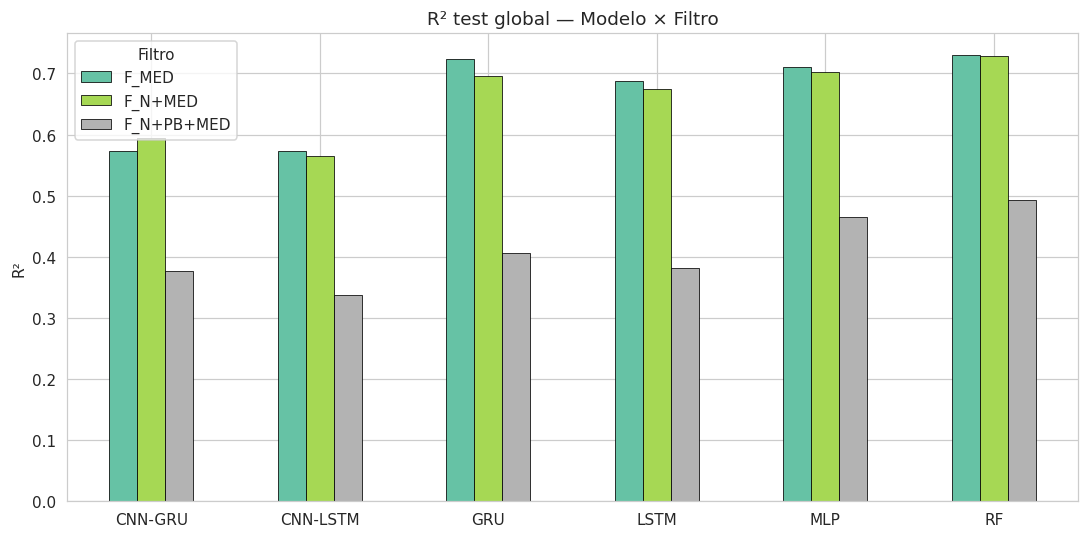

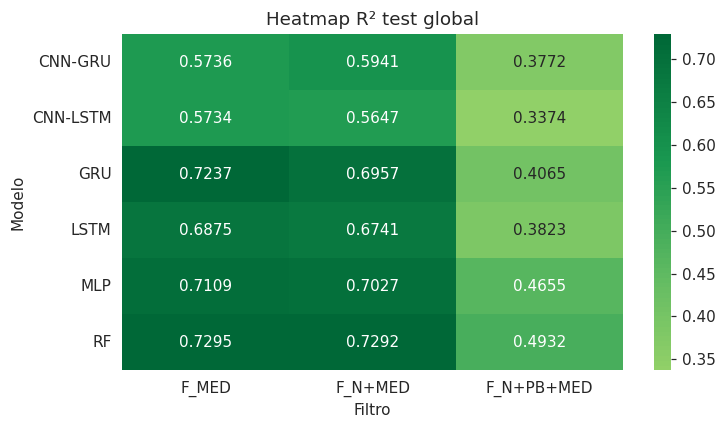

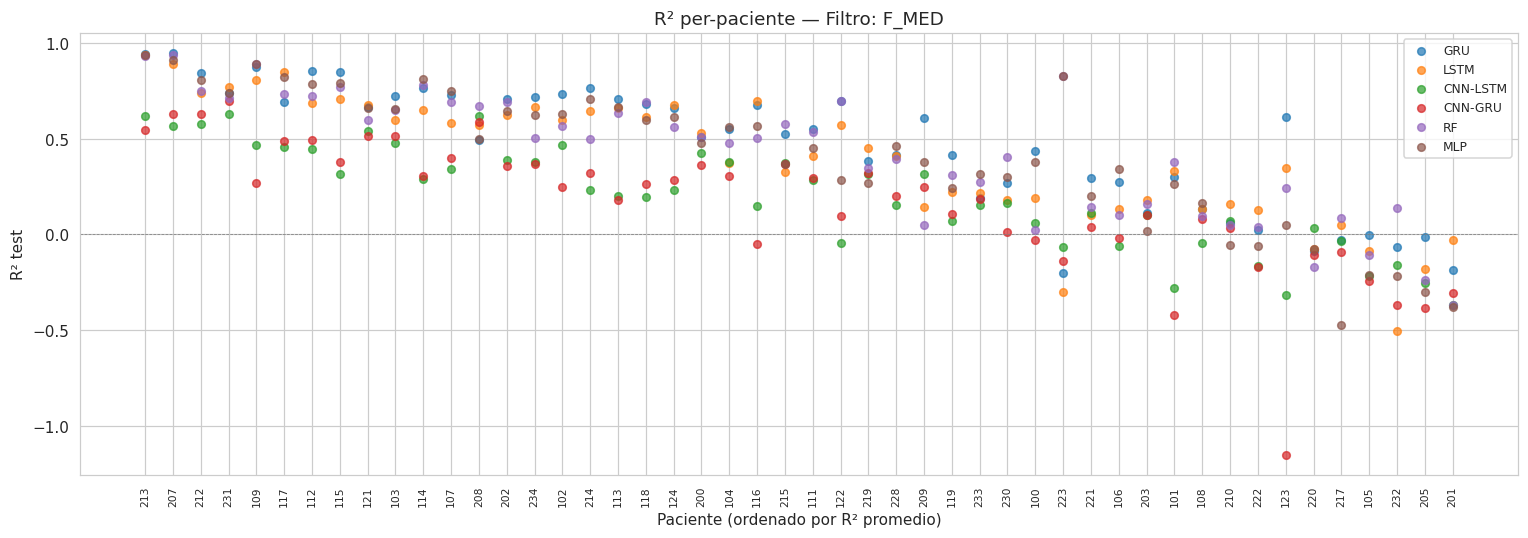

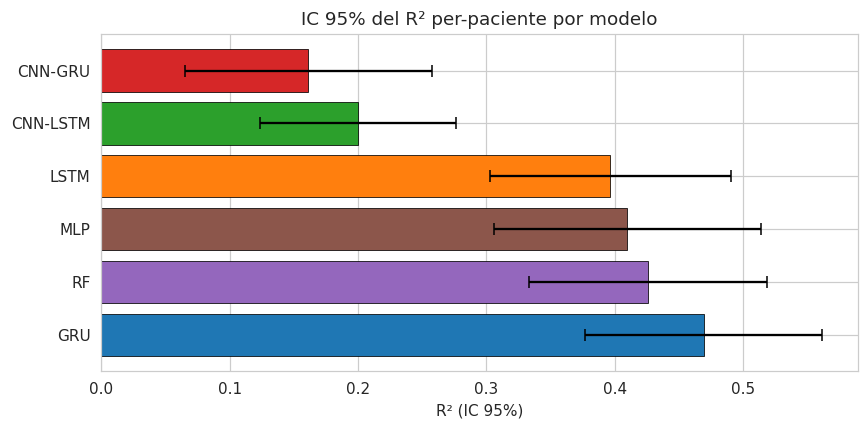

Visualizaciones guardadas.


In [17]:
# ══════════════════════════════════════════════════════════════════
# CELDA 18 — Visualizaciones
# ══════════════════════════════════════════════════════════════════

# 1. Barras agrupadas: R² test global por Modelo × Filtro
fig, ax = plt.subplots(figsize=(10, 5))
pivot_bar = df_global.pivot(index='Modelo', columns='Filtro', values='R2')
pivot_bar.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5)
ax.set_title('R² test global — Modelo × Filtro')
ax.set_ylabel('R²')
ax.set_xlabel('')
ax.axhline(0, color='grey', ls='--', lw=0.5)
ax.legend(title='Filtro')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'barras_nb4b_modelo_filtro.png'), dpi=150)
plt.show()

# 2. Heatmap: R² test
fig, ax = plt.subplots(figsize=(7, 4))
pivot_hm = df_global.pivot(index='Modelo', columns='Filtro', values='R2')
sns.heatmap(pivot_hm, annot=True, fmt='.4f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Heatmap R² test global')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'heatmap_nb4b.png'), dpi=150)
plt.show()

# 3. Scatter R² per-paciente (mejor filtro)
mejor_filtro = df_global.sort_values('R2', ascending=False).iloc[0]['Filtro']
df_sc = df_perpac[df_perpac.Filtro == mejor_filtro].copy()

# Ordenar pacientes por R² promedio
orden_pac = (df_sc.groupby('Paciente')['R2'].mean()
             .sort_values(ascending=False).index.tolist())
df_sc['Paciente'] = pd.Categorical(df_sc['Paciente'], categories=orden_pac, ordered=True)

fig, ax = plt.subplots(figsize=(14, 5))
for nom_m in df_sc.Modelo.unique():
    sub = df_sc[df_sc.Modelo == nom_m].sort_values('Paciente')
    ax.scatter(range(len(sub)), sub['R2'].values, label=nom_m,
               color=PALETA.get(nom_m, 'grey'), s=25, alpha=0.7)
ax.set_xticks(range(len(orden_pac)))
ax.set_xticklabels(orden_pac, rotation=90, fontsize=7)
ax.set_ylabel('R² test')
ax.set_xlabel('Paciente (ordenado por R² promedio)')
ax.set_title(f'R² per-paciente — Filtro: {mejor_filtro}')
ax.axhline(0, color='grey', ls='--', lw=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'r2_por_paciente.png'), dpi=150)
plt.show()

# 4. IC 95% barh
df_ic = pd.read_csv(os.path.join(RUTA_RESULTS, 'ic95_nb4b.csv'))
fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(df_ic))
ax.barh(y_pos, df_ic['μ_R2'], xerr=[df_ic['μ_R2'] - df_ic['IC95_inf'],
         df_ic['IC95_sup'] - df_ic['μ_R2']], color=[PALETA.get(m, 'grey') for m in df_ic.Modelo],
        edgecolor='black', linewidth=0.5, capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_ic.Modelo)
ax.set_xlabel('R² (IC 95%)')
ax.set_title('IC 95% del R² per-paciente por modelo')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'ic95_nb4b.png'), dpi=150)
plt.show()

print('Visualizaciones guardadas.')

## BLOQUE 12 — Conclusiones y exportación

Exportación de `config_NB4B.json` y verificación de artefactos generados.

In [18]:
# ══════════════════════════════════════════════════════════════════
# CELDA 19 — Conclusiones + config JSON + verificación
# ══════════════════════════════════════════════════════════════════

config = {
    'notebook': '04B_segmentos_60s.ipynb',
    'fecha': '2026-03-26',
    'seed': SEED,
    'fs': FS,
    'duracion_seg': DURACION_SEG,
    'beat_len': BEAT_LEN,
    'n_lookback': N_LOOKBACK,
    'prop_train': PROP_TRAIN,
    'n_reps': 1,
    'n_pacientes': len(REGISTROS_OK),
    'filtros': FILTROS_SEL,
    'modelos_dl': list(MODELOS_DL.keys()),
    'modelos_trad': list(MODELOS_TRAD.keys()),
    'dl_epochs': EPOCHS,
    'dl_batch_size': BATCH_SIZE,
    'dl_lr': LR,
    'dl_l2_reg': L2_REG,
    'dl_dropout': DROPOUT,
    'dl_patience_es': PATIENCE_ES,
    'rf_config': 'n_estimators=30, max_depth=10, max_features=sqrt, min_samples_leaf=2 (idéntico a NB1)',
    'mlp_config': 'hidden_layer_sizes=(128,64), max_iter=300, early_stopping=True, validation_fraction=0.15 (idéntico a NB1)',
    'nota_asesor': 'El modelo no debe memorizar a un solo paciente, sino aprender patrones generales y robustos',
    'enfoque': 'Pool intra-paciente: split temporal 80/20 por paciente, todos contribuyen a train y test',
    'inferencia': 'Para usar modelos en nuevos pacientes: cargar modelo + norm_{filtro}.json (mu/std), aplicar mismo filtro y pipeline de latidos',
    'criterio_modelos': {
        'DL_top3_NB2': {'GRU': 0.6603, 'LSTM': 0.6584, 'CNN-LSTM': 0.6559},
        'DL_4_NB2': {'GRU': 0.6603, 'LSTM': 0.6584, 'CNN-LSTM': 0.6559, 'CNN-GRU': 0.6524},
        'Trad_2_NB1': {'RF': 0.6264, 'MLP': 'NB1'},
    },
}

with open(os.path.join(RUTA_RESULTS, 'config_NB4B.json'), 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print('Guardado: config_NB4B.json')

# ── Verificación de artefactos ────────────────────────────────────
esperados = [
    'metadata_segmentos_60s.csv',
    'resultados_nb4b_global.csv',
    'checkpoint_nb4b.csv',
    'resultados_nb4b_por_paciente.csv',
    'tabla_r2_train_test_nb4b.csv',
    'resumen_nb4b.csv',
    'ic95_nb4b.csv',
    'wilcoxon_nb4b.csv',
    'config_NB4B.json',
    'ejemplo_segmentos_60s.png',
    'ic95_nb4b.png',
    'barras_nb4b_modelo_filtro.png',
    'heatmap_nb4b.png',
    'boxplot_nb4b.png',
    'r2_por_paciente.png',
]

# Modelos guardados (6 modelos × 3 filtros = 18 archivos)
# + 3 archivos de normalización (1 por filtro)
modelos_esperados = []
for f in FILTROS_SEL:
    modelos_esperados.append(f'norm_{f}.json')
    for m in MODELOS_DL:
        modelos_esperados.append(f'modelo_{m}_{f}.keras')
    for m in MODELOS_TRAD:
        modelos_esperados.append(f'modelo_{m}_{f}.pkl')

print('\n── Verificación de artefactos ──')
ok, faltan = 0, 0
for nombre in esperados:
    ruta = os.path.join(RUTA_RESULTS, nombre)
    existe = os.path.exists(ruta)
    marca = '✓' if existe else '✗'
    print(f'  {marca}  {nombre}')
    ok += existe; faltan += (not existe)

print('\n── Verificación de modelos + normalización ──')
for nombre in modelos_esperados:
    ruta = os.path.join(RUTA_MODELOS, nombre)
    existe = os.path.exists(ruta)
    marca = '✓' if existe else '✗'
    print(f'  {marca}  modelos/{nombre}')
    ok += existe; faltan += (not existe)

print(f'\nTotal: {ok}/{len(esperados)+len(modelos_esperados)} generados, {faltan} faltantes.')

# ── Resumen final ─────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'  NB4B COMPLETADO')
print(f'  Modelos: {list(MODELOS_DL.keys()) + list(MODELOS_TRAD.keys())}')
print(f'  Filtros: {FILTROS_SEL}')
print(f'  Entrenamientos: {len(df_global)}')
print(f'  Mejor R² test global: {df_global.R2.max():+.4f}')
print(f'  Modelos guardados en: {RUTA_MODELOS}')
print(f'  Para inferencia: modelo + norm_{{filtro}}.json (mu/std)')
print(f'{"="*65}')

Guardado: config_NB4B.json

── Verificación de artefactos ──
  ✓  metadata_segmentos_60s.csv
  ✓  resultados_nb4b_global.csv
  ✓  checkpoint_nb4b.csv
  ✓  resultados_nb4b_por_paciente.csv
  ✓  tabla_r2_train_test_nb4b.csv
  ✓  resumen_nb4b.csv
  ✓  ic95_nb4b.csv
  ✓  wilcoxon_nb4b.csv
  ✓  config_NB4B.json
  ✓  ejemplo_segmentos_60s.png
  ✓  ic95_nb4b.png
  ✓  barras_nb4b_modelo_filtro.png
  ✓  heatmap_nb4b.png
  ✓  boxplot_nb4b.png
  ✓  r2_por_paciente.png

── Verificación de modelos + normalización ──
  ✓  modelos/norm_F_N+PB+MED.json
  ✓  modelos/modelo_GRU_F_N+PB+MED.keras
  ✓  modelos/modelo_LSTM_F_N+PB+MED.keras
  ✓  modelos/modelo_CNN-LSTM_F_N+PB+MED.keras
  ✓  modelos/modelo_CNN-GRU_F_N+PB+MED.keras
  ✓  modelos/modelo_RF_F_N+PB+MED.pkl
  ✓  modelos/modelo_MLP_F_N+PB+MED.pkl
  ✓  modelos/norm_F_N+MED.json
  ✓  modelos/modelo_GRU_F_N+MED.keras
  ✓  modelos/modelo_LSTM_F_N+MED.keras
  ✓  modelos/modelo_CNN-LSTM_F_N+MED.keras
  ✓  modelos/modelo_CNN-GRU_F_N+MED.keras
  ✓  modelos/

## BLOQUE 13 — Experimento Adicional: CNN con TimeDistributed (TD-CNN)

**Motivación:** Las arquitecturas CNN-LSTM y CNN-GRU originales aplican `Conv1D`
sobre los **5 pasos de lookback**, lo que con N_LOOKBACK=5
resulta en kernels que barren una secuencia demasiado corta para extraer patrones útiles.
Además, `MaxPooling1D(2)` reduce 5 → 2 timesteps antes del RNN, perdiendo información.

**Diseño corregido — TimeDistributed CNN + RNN:**
1. La CNN se aplica **independientemente a cada uno de los 5 latidos** (sobre sus 256 muestras),
   extrayendo la morfología de cada latido.
2. El RNN (LSTM o GRU) procesa la **secuencia de 5 representaciones comprimidas** (64-dim).

```
Latido_1 (256) → CNN → 64-dim ─┐
Latido_2 (256) → CNN → 64-dim  ├→ LSTM/GRU(64) → Dense(256) → Latido_6 predicho
Latido_3 (256) → CNN → 64-dim  │
Latido_4 (256) → CNN → 64-dim  │
Latido_5 (256) → CNN → 64-dim ─┘
```

| Aspecto | CNN original | TD-CNN (nuevo) |
|---------|-------------|----------------|
| Conv1D opera sobre | 5 pasos de tiempo | 256 muestras de cada latido |
| MaxPooling destruye | 5 → 2 timesteps | 256 → 64 muestras (interno) |
| Input al RNN | 2 pasos colapsados | 5 vectores morfológicos (64-dim) |

**Total:** 3 filtros × 2 modelos = **6 entrenamientos adicionales**.

In [19]:
# ══════════════════════════════════════════════════════════════════
# CELDA 20 — Arquitecturas TD-CNN-LSTM y TD-CNN-GRU
# ══════════════════════════════════════════════════════════════════

def build_td_cnn_lstm(input_shape, out_dim):
    """TimeDistributed CNN + LSTM.
    Conv1D aplicada sobre las 256 muestras de cada latido (extrae morfologia).
    El LSTM procesa la secuencia de 5 vectores comprimidos (64-dim cada uno).
    input_shape = (N_LOOKBACK, BEAT_LEN) = (5, 256)
    """
    n_steps, beat_len = input_shape
    return keras.Sequential([
        layers.Input(shape=input_shape),                          # (5, 256)
        layers.Reshape((n_steps, beat_len, 1)),                   # (5, 256, 1)
        # CNN extrae morfologia de cada latido por separado
        layers.TimeDistributed(
            layers.Conv1D(64, 7, activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(L2_REG))
        ),                                                        # (5, 256, 64)
        layers.TimeDistributed(
            layers.Conv1D(128, 5, activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(L2_REG))
        ),                                                        # (5, 256, 128)
        layers.TimeDistributed(layers.MaxPooling1D(4)),           # (5, 64, 128)
        layers.TimeDistributed(
            layers.Conv1D(64, 3, activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(L2_REG))
        ),                                                        # (5, 64, 64)
        layers.TimeDistributed(layers.GlobalAveragePooling1D()),  # (5, 64)
        # LSTM procesa la secuencia de representaciones morfologicas
        layers.LSTM(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim)
    ])


def build_td_cnn_gru(input_shape, out_dim):
    """TimeDistributed CNN + GRU. Idem a TD-CNN-LSTM con GRU recurrente."""
    n_steps, beat_len = input_shape
    return keras.Sequential([
        layers.Input(shape=input_shape),                          # (5, 256)
        layers.Reshape((n_steps, beat_len, 1)),                   # (5, 256, 1)
        layers.TimeDistributed(
            layers.Conv1D(64, 7, activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(L2_REG))
        ),
        layers.TimeDistributed(
            layers.Conv1D(128, 5, activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(L2_REG))
        ),
        layers.TimeDistributed(layers.MaxPooling1D(4)),
        layers.TimeDistributed(
            layers.Conv1D(64, 3, activation='relu', padding='same',
                         kernel_regularizer=regularizers.l2(L2_REG))
        ),
        layers.TimeDistributed(layers.GlobalAveragePooling1D()),  # (5, 64)
        layers.GRU(64, kernel_regularizer=regularizers.l2(L2_REG)),
        layers.Dropout(DROPOUT),
        layers.Dense(out_dim)
    ])


MODELOS_TD = {
    'TD-CNN-LSTM': build_td_cnn_lstm,
    'TD-CNN-GRU' : build_td_cnn_gru,
}

# Verificar que la compilacion funciona
_test_shape = (N_LOOKBACK, BEAT_LEN)
for nom, fn in MODELOS_TD.items():
    m_test = fn(_test_shape, BEAT_LEN)
    m_test.build((None, *_test_shape))
    params = m_test.count_params()
    print(f'{nom}: {params:,} parámetros')
    del m_test
gc.collect()
print(f'Arquitecturas TD-CNN listas. Input: {_test_shape}  Output: {BEAT_LEN}')

TD-CNN-LSTM: 115,904 parámetros
TD-CNN-GRU: 107,840 parámetros
Arquitecturas TD-CNN listas. Input: (5, 256)  Output: 256


In [20]:
# ══════════════════════════════════════════════════════════════════
# CELDA 21 — Entrenamiento TD-CNN: 3 filtros x 2 modelos = 6
#   Reutiliza construir_pool_global() y entrenar_dl() de BLOQUE 10.
#   Carga parametros de normalizacion desde JSON existente.
# ══════════════════════════════════════════════════════════════════

CKPT_TD_GLOBAL = os.path.join(RUTA_RESULTS, 'checkpoint_td_cnn.csv')
CKPT_TD_PERPAC = os.path.join(RUTA_RESULTS, 'checkpoint_td_cnn_perpac.csv')

filas_td_global = []
filas_td_perpac = []
YA_HECHO_TD    = set()

if os.path.exists(CKPT_TD_GLOBAL):
    filas_td_global = pd.read_csv(CKPT_TD_GLOBAL).to_dict('records')
    for r in filas_td_global:
        YA_HECHO_TD.add((r['Filtro'], r['Modelo']))
    print(f'Checkpoint global: {len(filas_td_global)} filas previas.')
if os.path.exists(CKPT_TD_PERPAC):
    filas_td_perpac = pd.read_csv(CKPT_TD_PERPAC).to_dict('records')
    print(f'Checkpoint per-pac: {len(filas_td_perpac)} filas previas.')

t0_td = time.perf_counter()

for nom_f in FILTROS_SEL:
    print(f'\n{"="*65}')
    print(f'  FILTRO: {nom_f}')
    print(f'{"="*65}')

    # Construir pool (mismo procedimiento que BLOQUE 10)
    X_train, y_train, X_test, y_test, pids_tr, pids_te, df_st = construir_pool_global(nom_f)

    # Cargar norm ya guardada (mismos parametros → comparacion justa con BLOQUE 10)
    ruta_norm = os.path.join(RUTA_MODELOS, f'norm_{nom_f}.json')
    with open(ruta_norm) as f_n:
        norm = json.load(f_n)
    mu, std = norm['mu'], norm['std']
    X_train_n = ((X_train - mu) / std).astype(np.float32)
    X_test_n  = ((X_test  - mu) / std).astype(np.float32)
    y_train_n = ((y_train - mu) / std).astype(np.float32)
    y_test_n  = ((y_test  - mu) / std).astype(np.float32)
    print(f'  Norm cargada: mu={mu:.6f}, std={std:.6f}')
    print(f'  Pool: train={len(X_train_n)} test={len(X_test_n)} pacientes={len(df_st)}')

    for nom_td, build_fn in MODELOS_TD.items():
        clave    = (nom_f, nom_td)
        ruta_mod = os.path.join(RUTA_MODELOS, f'modelo_{nom_td}_{nom_f}.keras')

        if clave in YA_HECHO_TD:
            print(f'  {nom_td}: skip (ya hecho)')
            continue

        print(f'  {nom_td}: entrenando... ', end='', flush=True)
        met, model_td = entrenar_dl(nom_td, build_fn, X_train_n, y_train_n,
                                     X_test_n, y_test_n)

        if met:
            model_td.save(ruta_mod)
            print(f'R2_train={met["R2_train"]:+.4f} R2_test={met["R2"]:+.4f} '
                  f't={met["t_fit_s"]:.0f}s ep={met["epochs_ran"]}')
            print(f'    Modelo guardado: modelo_{nom_td}_{nom_f}.keras')

            fila = {'Filtro': nom_f, 'Modelo': nom_td,
                    'n_pacientes': len(df_st),
                    'n_ventanas_train': len(X_train_n),
                    'n_ventanas_test':  len(X_test_n), **met}
            filas_td_global.append(fila)
            YA_HECHO_TD.add(clave)

            # Metricas per-paciente
            for pid in REGISTROS_OK:
                mask_te = pids_te == pid
                if mask_te.sum() == 0:
                    continue
                Xp_te   = X_test_n[mask_te]
                yp_te   = y_test_n[mask_te]
                yp_pred = model_td.predict(Xp_te, batch_size=BATCH_SIZE, verbose=0)
                met_p   = calcular_metricas(yp_te, yp_pred, 0)
                if met_p:
                    filas_td_perpac.append({
                        'Filtro': nom_f, 'Modelo': nom_td, 'Paciente': pid,
                        **met_p
                    })

            pd.DataFrame(filas_td_global).to_csv(CKPT_TD_GLOBAL, index=False)
            pd.DataFrame(filas_td_perpac).to_csv(CKPT_TD_PERPAC, index=False)
            print(f'    Checkpoint guardado ({len(filas_td_global)} modelos acumulados)')

        del model_td; gc.collect()

    del X_train, y_train, X_test, y_test, X_train_n, X_test_n
    del y_train_n, y_test_n, pids_tr, pids_te
    gc.collect()

# Guardar resultados finales
df_td_global = pd.DataFrame(filas_td_global)
df_td_perpac = pd.DataFrame(filas_td_perpac)
df_td_global.to_csv(os.path.join(RUTA_RESULTS, 'resultados_td_cnn_global.csv'), index=False)
df_td_perpac.to_csv(os.path.join(RUTA_RESULTS, 'resultados_td_cnn_por_paciente.csv'), index=False)

t_td = (time.perf_counter() - t0_td) / 60
print(f'{"="*65}')
print(f'  TD-CNN COMPLETADO — {t_td:.1f} min')
print(f'  Global: {len(df_td_global)} filas  |  Per-paciente: {len(df_td_perpac)} filas')
print(f'{"="*65}')
df_td_global


  FILTRO: F_N+PB+MED
  Norm cargada: mu=-0.036191, std=0.222156
  Pool: train=3086 test=795 pacientes=48
  TD-CNN-LSTM: entrenando... R2_train=+0.4700 R2_test=+0.3447 t=112s ep=69
    Modelo guardado: modelo_TD-CNN-LSTM_F_N+PB+MED.keras
    Checkpoint guardado (1 modelos acumulados)
  TD-CNN-GRU: entrenando... R2_train=+0.2195 R2_test=+0.1835 t=34s ep=19
    Modelo guardado: modelo_TD-CNN-GRU_F_N+PB+MED.keras
    Checkpoint guardado (2 modelos acumulados)

  FILTRO: F_N+MED
  Norm cargada: mu=-0.360891, std=0.409455
  Pool: train=3086 test=795 pacientes=48
  TD-CNN-LSTM: entrenando... R2_train=+0.5525 R2_test=+0.5441 t=30s ep=16
    Modelo guardado: modelo_TD-CNN-LSTM_F_N+MED.keras
    Checkpoint guardado (3 modelos acumulados)
  TD-CNN-GRU: entrenando... R2_train=+0.5744 R2_test=+0.5620 t=29s ep=17
    Modelo guardado: modelo_TD-CNN-GRU_F_N+MED.keras
    Checkpoint guardado (4 modelos acumulados)

  FILTRO: F_MED
  Norm cargada: mu=-0.360794, std=0.409487
  Pool: train=3086 test=795 

,Filtro,Modelo,n_pacientes,n_ventanas_train,n_ventanas_test,R2,MSE,RMSE,MAE,DTW,Latencia_ms,R2_train,t_fit_s,epochs_ran
0,F_N+PB+MED,TD-CNN-LSTM,48,3086,795,0.3447,0.735260,0.857473,0.462111,16.2510,0.3043,0.4700,111.840,69
1,F_N+PB+MED,TD-CNN-GRU,48,3086,795,0.1835,0.916167,0.957166,0.555453,19.5874,0.4692,0.2195,34.230,19
2,F_N+MED,TD-CNN-LSTM,48,3086,795,0.5441,0.515727,0.718141,0.454910,14.8471,0.2307,0.5525,29.974,16
3,F_N+MED,TD-CNN-GRU,48,3086,795,0.5620,0.495433,0.703870,0.444402,14.3289,0.2422,0.5744,28.642,17
4,F_MED,TD-CNN-LSTM,48,3086,795,0.5394,0.521014,0.721813,0.457402,15.0486,0.2414,0.5484,27.766,16
5,F_MED,TD-CNN-GRU,48,3086,795,0.5498,0.509254,0.713620,0.449129,14.4203,0.2356,0.5588,32.327,16


=== Comparacion Global R² test ===
  TD-CNN = nuevo diseño TimeDistributed | CNN = diseno original NB2


Filtro,F_MED,F_N+MED,F_N+PB+MED
Modelo,,,
GRU,+0.7237,+0.6957,+0.4065
LSTM,+0.6875,+0.6741,+0.3823
CNN-LSTM,+0.5734,+0.5647,+0.3374
CNN-GRU,+0.5736,+0.5941,+0.3772
TD-CNN-LSTM,+0.5394,+0.5441,+0.3447
TD-CNN-GRU,+0.5498,+0.5620,+0.1835


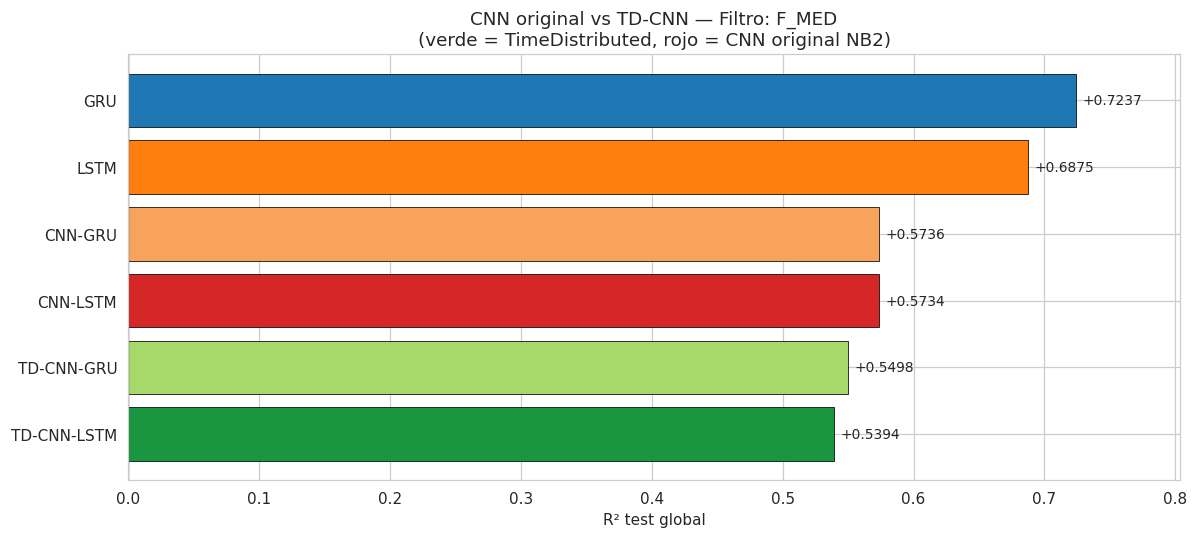


=== Wilcoxon per-paciente — F_MED ===
  TD-CNN-LSTM vs CNN-LSTM: datos insuficientes (0 pares)
  TD-CNN-GRU vs CNN-GRU: datos insuficientes (0 pares)
  TD-CNN-LSTM vs GRU: datos insuficientes (0 pares)
  TD-CNN-GRU vs GRU: datos insuficientes (0 pares)
Guardado: comparacion_td_cnn.png


In [21]:
# ══════════════════════════════════════════════════════════════════
# CELDA 22 — Comparacion TD-CNN vs CNN original vs GRU
# ══════════════════════════════════════════════════════════════════
from scipy.stats import wilcoxon as wxon

# Cargar resultados originales
df_orig    = pd.read_csv(os.path.join(RUTA_RESULTS, 'resultados_nb4b_global.csv'))
df_orig_pp = pd.read_csv(os.path.join(RUTA_RESULTS, 'resultados_nb4b_por_paciente.csv'))

# Tabla global comparativa
modelos_cmp = ['GRU', 'LSTM', 'CNN-LSTM', 'CNN-GRU', 'TD-CNN-LSTM', 'TD-CNN-GRU']
df_orig_sub = df_orig[df_orig.Modelo.isin(modelos_cmp)][['Filtro','Modelo','R2','R2_train']].copy()
df_td_sub   = df_td_global[['Filtro','Modelo','R2','R2_train']].copy()
df_cmp_g    = pd.concat([df_orig_sub, df_td_sub], ignore_index=True)
df_cmp_g['GAP'] = (df_cmp_g['R2_train'] - df_cmp_g['R2']).round(4)

print('=== Comparacion Global R² test ===')
print('  TD-CNN = nuevo diseño TimeDistributed | CNN = diseno original NB2')
tabla_cmp = (df_cmp_g.pivot_table(index='Modelo', columns='Filtro', values='R2', aggfunc='first')
             .reindex(modelos_cmp))
display(tabla_cmp.style.background_gradient(cmap='RdYlGn', axis=None).format('{:+.4f}'))

# Grafico de barras: mejor filtro
mejor_f = df_orig.loc[df_orig.R2.idxmax(), 'Filtro']
df_bar  = df_cmp_g[df_cmp_g.Filtro == mejor_f].sort_values('R2', ascending=True)

PALETA_CMP = {
    'TD-CNN-LSTM': '#1a9641', 'TD-CNN-GRU': '#a6d96a',
    'GRU'        : '#1f77b4', 'LSTM'      : '#ff7f0e',
    'CNN-LSTM'   : '#d62728', 'CNN-GRU'   : '#f7a35c',
}

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_bar['Modelo'], df_bar['R2'],
               color=[PALETA_CMP.get(m, 'grey') for m in df_bar['Modelo']],
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, df_bar['R2']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('R² test global')
ax.set_title(f'CNN original vs TD-CNN — Filtro: {mejor_f}\n'
             f'(verde = TimeDistributed, rojo = CNN original NB2)')
ax.set_xlim(0, df_bar['R2'].max() + 0.08)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_RESULTS, 'comparacion_td_cnn.png'), dpi=150)
plt.show()

# Wilcoxon per-paciente
df_all_pp = pd.concat([
    df_orig_pp[['Filtro','Modelo','Paciente','R2']],
    df_td_perpac[['Filtro','Modelo','Paciente','R2']]
], ignore_index=True)
df_f = df_all_pp[df_all_pp.Filtro == mejor_f]

pares_interes = [
    ('TD-CNN-LSTM', 'CNN-LSTM'),
    ('TD-CNN-GRU',  'CNN-GRU'),
    ('TD-CNN-LSTM', 'GRU'),
    ('TD-CNN-GRU',  'GRU'),
]

print(f'\n=== Wilcoxon per-paciente — {mejor_f} ===')
rows_wx = []
for m1, m2 in pares_interes:
    r1 = df_f[df_f.Modelo == m1].set_index('Paciente')['R2']
    r2 = df_f[df_f.Modelo == m2].set_index('Paciente')['R2']
    comun = r1.index.intersection(r2.index)
    if len(comun) < 10:
        print(f'  {m1} vs {m2}: datos insuficientes ({len(comun)} pares)')
        continue
    diff = r1.loc[comun].values - r2.loc[comun].values
    if (diff == 0).all():
        continue
    _, p = wxon(diff)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    mu1, mu2 = r1.loc[comun].mean(), r2.loc[comun].mean()
    ganador = m1 if mu1 > mu2 else m2
    print(f'  {m1} (mu={mu1:.4f}) vs {m2} (mu={mu2:.4f}): p={p:.4f} {sig}  → mejor: {ganador}')
    rows_wx.append({'par': f'{m1} vs {m2}', 'mu_m1': round(mu1,4), 'mu_m2': round(mu2,4),
                    'p_value': round(p,4), 'sig': sig, 'mejor': ganador})

if rows_wx:
    pd.DataFrame(rows_wx).to_csv(os.path.join(RUTA_RESULTS, 'wilcoxon_td_cnn.csv'), index=False)
    print('\nGuardado: wilcoxon_td_cnn.csv')
print('Guardado: comparacion_td_cnn.png')

## BLOQUE 14 — Interpretación de Resultados TD-CNN

### Resultados obtenidos (R² test global)

| Modelo | F_MED | F_N+MED | F_N+PB+MED |
|--------|-------|---------|------------|
| GRU | **0.7237** | **0.6957** | **0.4065** |
| LSTM | 0.6875 | 0.6741 | 0.3823 |
| CNN-LSTM | 0.5734 | 0.5647 | 0.3374 |
| CNN-GRU | 0.5736 | 0.5941 | 0.3772 |
| TD-CNN-LSTM | 0.5394 | 0.5441 | 0.3447 |
| TD-CNN-GRU | 0.5498 | 0.5620 | 0.1835 |



